# Recommended pipeline guidelines
<div style="text-align: justify">

The following document is dedicated to present a detailed specification of the analysis pipeline using <i>biocluster package</i> to do the study of the <b>Pareto Front solutions from gene clustering algorithms</b>, considering explanation of the theory background, graphical aids (using diagrams) and the demonstration of the functions developed for this library. As an introduction, I provide a summary of the contents of this document.<br>

**Abstract:** Multi-Objective clustering using gene expression data is a complex task in bioinformatics that seeks to group genes based on behavior patterns under diverse experimental conditions, selecting those that optimize multiple criteria (objective functions). Considering multiple criteria makes the problem even harder, in particular if they are conflicting **[1, 3]**. If we ask for an approach that simplifies it into a single criterion, it is not effective because single-objective approaches simplify the difficulty of the optimization problem, losing effectiveness when it comes to obtaining a diversity of solutions that allow the frontier to be explored with relative ease **[8, 5]**. Exploring this space requires an unreasonable amount of
time due to the huge space of possible solutions available and the hardness of the process. Therefore, the use of metaheuristics is an alternative to obtain quality solutions within a reasonable timeframe. The result is a set of Pareto-optimal solutions (Figure 1) **[8]**. This set of solutions needs to be characterized in terms of their similarities and differences to understand the influence of genes and, consequently, the metabolic processes, molecular functions, and cell structures involved in the main component under study **[4, 2]**. The characterization of this set drives the execution of this project: <b>to create a freely available Python package that supports a comprehensive characterization of these solutions</b>. 
</div>


<div align="center">

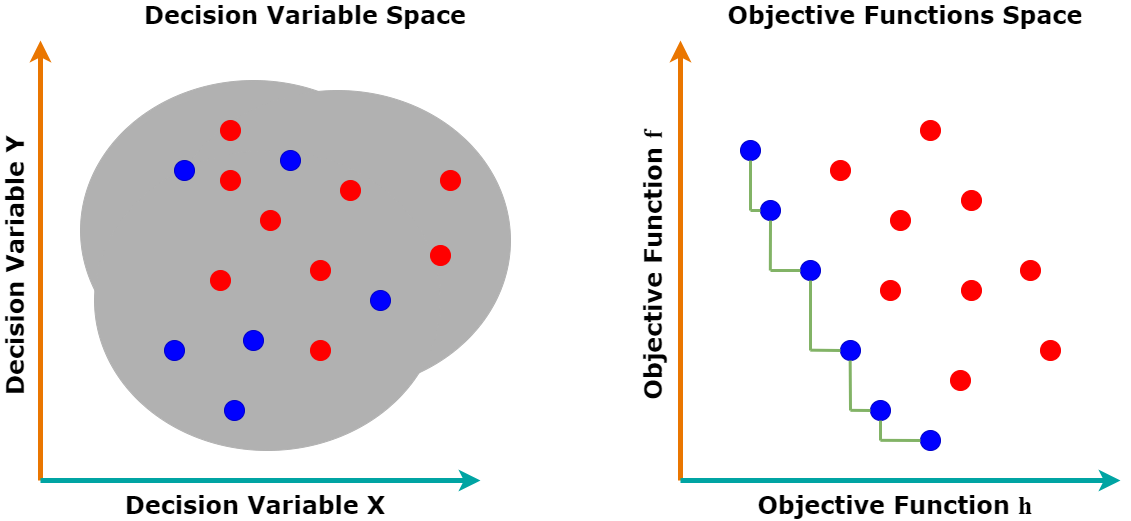
  <figcaption style="font-size: 0.9em; color: #FFF; margin-top: 8px; text-align: justify;">
    <strong>Figure 1.</strong> Multi-objective clustering algorithms compare multiple solutions generated by evaluating their Pareto dominance and quality, selecting those that satisfy Pareto optimal conditions and improve quality most. Pareto Front example in a continuous solution space. It is relevant to note that the order in the decision variable space does not necessarily have to match the order in the objective space. The Pareto Front conditions are [6]:<br>
    <sup>1</sup> <em>Non-dominance:</em> one solution is not absolutely better than another in all constraints.<br>
    <sup>2</sup> <em>Trade-off:</em> improving one objective (or criterion) means worsening at least one of the others.<br><br>
  </figcaption>
</div>

<div style="text-align: justify">

**Objectives**:
- To provide procedures that facilitate finding similarities and differences between all the solutions obtained, both quantitatively and qualitatively.
- To offer visual tools aimed at displaying the final outputs and summarizing the results (data structures, graphs, documents and more).
- To register the package for installation via pip (Package installer for Python).
- Provide detailed documentation and tutorials with examples that allow users to apply the package’s tools to their own experiment results.

**Scopes**:
- To provide a package capable of supporting and being integrated for characterization of the results of various experimental investigations.
- Encourage the Python and scientific community to provide feedback for continuous improvement. Even, more applications for this project.
- To be used for GUI creations or within larger projects that aim to support activities related to genetic studies.

**Sections**:
1. Reading solutions
2. GO Resources
3. Mapping Gene Symbols to Entrez ID.
4. Solution Cluster Matrix
5. GO Semantic Similarity
6. Consensus Clustering
7. GO Enrichment and Graphs for Analysis
8. Solutions identification
9. Summary study from solutions

</div>

In [1]:
# ---------------------------------------------------------------------
# STANDARD LIBRARY IMPORTS
# ---------------------------------------------------------------------
import contextlib
import multiprocessing  # Enables parallel execution and controls the start method below.
import os  # Operating system utilities (env vars, paths).
import warnings  # Used to silence noisy, non-actionable warnings.
from pathlib import Path  # Avoids errors related to a computer's directory format.
from pprint import pprint  # Pretty prints, a more elegant way to display things.

import numpy as np  # Handling of mathematical structures.
import pandas as pd  # Handling of dataframes.

#Note: On my computer, somehow, I got an error about core detection
#so I need to put these lines of code. Actually, maybe it is not needed for you.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "6")
with contextlib.suppress(RuntimeError):
    multiprocessing.set_start_method("spawn", force=True)
warnings.filterwarnings(
    "ignore",
    message=".*Could not find the number of physical cores.*",
)

In [2]:
# ---------------------------------------------------------------------
# PACKAGE IMPORTS
# ---------------------------------------------------------------------

"""
This section gathers every component built within the library, each one a fundamental
support at some stage of the pipeline. If the question arises as to why there is so little
coupling between components, the answer is simple:
    1. It is good practice for functions to be individually useful without depending
    on others at execution level.
    2. Science always leaves the door open for a limited method or pipeline, so other
    people wanting to build something more sophisticated won't need to reinvent
    previous steps.
"""

# Components related to reading, saving, and handling the solution file format.
# Components dedicated to each pipeline step; these deserve their own explanation.
import biocluster.clustering.consensus_matrix as consensus_matrix  # Builds the consensus matrix (co-occurrence proportion of gene pairs across all solutions).
import biocluster.clustering.he_clustering as he_clustering  # Performs hierarchical clustering and renders the resulting dendrogram.
import biocluster.clustering.he_inconsistency_clustering as he_clustering_inc
import biocluster.clustering.jaccard_values as jaccard_values  # Computes Jaccard indices at both solution and cluster level.
import biocluster.clustering.solutioncluster_matrix as solution_cluster_matrix  # Reshapes a solution matrix into per-cluster gene groupings.
import biocluster.go.gene_similarity as gene_similarity  # Builds a biological (semantic) distance/similarity matrix between genes.
import biocluster.go.go_enrichment as go_enbrichment  # Applies gene enrichment, returning Gene Ontology terms.
import biocluster.go.go_utils as go_utils  # Downloads and manages Gene Ontology resources (obo, gaf, gene_info).

# Components dedicated to applying gene ontology analyses.
import biocluster.go.mapping_entrez as mapping_entrez  # Converts any gene identifier to Entrez ID.

# This component is dedicated to studying the genes that solutions tend not to share,
# also explained further in the final section.
import biocluster.summary.consensus_distance as gos  # Summarizes the solutions most distant from the consensus solution.
import biocluster.summary.gene_overlap as cds  # Summarizes gene overlap among a sub-group of genes.
import biocluster.summary.semantic_structural_discrepancy as ssd  # Summarizes solutions with a Wang/Jaccard similarity discrepancy.
import biocluster.utils.actions as actions  # General-purpose helpers (e.g. saving dataframes to disk).
import biocluster.utils.read_solution as read_solution  # Reads the raw solutions file into a solution matrix and gene list.
import biocluster.visualization.go_hierarchical_network as go_he_network  # Hierarchical (tree-structured) Gene Ontology network visualization.
import biocluster.visualization.go_network as go_network  # Gene Ontology interaction network visualization.
import biocluster.visualization.go_plots as go_plots  # Gene-ratio and q-score plots for enrichment results.

# Gene ontology visualizations; each will be explained during the walkthrough
# together with references to their supporting literature.
import biocluster.visualization.heatmaps as heatmaps  # Clustered/dual heatmaps for similarity and consensus matrices.

In [3]:
# ---------------------------------------------------------------------
# PATHS
# ---------------------------------------------------------------------
# All paths are resolved relative to this notebook's own location instead of
# being hard-coded to a specific machine, so the notebook keeps working after
# being cloned, moved, or run on another computer.
BASE_DIR = Path.cwd()                                            # Directory this notebook is being executed from (examples/).
DATA_DIR = BASE_DIR / "examples_tests_files"                     # Folder holding the example solution files.
RESOURCES_DIR = BASE_DIR / "resources"                           # Folder holding the shared Gene Ontology resources.
RESULTS_DIR = BASE_DIR / "results"                               # Folder where generated figures, matrices, and dataframes are saved.
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

solution_file_path = DATA_DIR / "archivo_prueba_1_116_500.csv"   # Example Pareto Front solution matrix.
gene_info_path = RESOURCES_DIR / "goa_human.gene_info"           # NCBI gene_info file for symbol/Entrez mapping.
obo_path = RESOURCES_DIR / "go.obo"                              # Gene Ontology term definitions and hierarchy.
gaf_path = RESOURCES_DIR / "goa_human.gaf"                       # Gene Ontology annotation file (gene-to-term mapping).

## Reading Solutions.

<div style="text-align: justify">

The first step of the clustering analysis pipeline is loading the solution matrices from disk. A **solution** encodes, for each gene, the cluster label assigned in a given clustering run. Multiple solutions (e.g., from different algorithms, parameter settings, or bootstrap runs) can be stored as rows in the same file, where each column corresponds to a gene. Supported file formats: **CSV** (`.csv`), **fixed-width text** (`.fwf`, `.txt`), and **pickled pandas DataFrames** (`.pkl`). The format is automatically inferred from the file extension.

Two layouts are accepted:

**1. Without a solution index column** — each row is a solution, each column a gene:

Gene_ID_1,Gene_ID_2,Gene_ID_3,Gene_ID_4,...  
1,2,2,1,..  
1,2,1,1...  
2,2,2,1...  

**2. With a solution index column** — the first column labels each solution:

sol,Gene_ID_1,Gene_ID_2,Gene_ID_3,Gene_ID_4,...  
sol_1,1,2,2,1,..  
sol_2,1,2,1,1...  
sol_3,2,2,2,1...  

For fixed-width files (`.fwf`/`.txt`), columns are expected to be aligned by consistent whitespace padding rather than delimiters. CSV files support automatic delimiter detection (comma, semicolon, tab, etc.), so consistency within a file is required but the exact separator does not need to be known in advance. Any column named `Unnamed*` (typically produced by an unlabeled index column when exporting from pandas) is automatically dropped, and all remaining values are coerced to numeric type. Non-numeric entries that cannot be converted become `NaN`. The output of this step is always a standardized pair: a NumPy matrix of cluster labels and a list of the corresponding gene names (column headers).

### Functions

| Stage | Function | Description |
|---|---|---|
| Reading Solutions | `read_solutions_file(filepath)` | Infers the file format from its extension, dispatches to the appropriate reader, cleans the result, and returns `(matrix, gene_names)`. |

</div>

In [4]:
# Extracting example file from dedicated directory.
solutions_raw = pd.read_csv(str(solution_file_path))
print(f"\nSolutions (first 10 of {len(solutions_raw)}):")
display(solutions_raw.head(10))

# Reading solution & gene identificators mapping.
Solution_Matrix, genes = read_solution.read_solutions_file(solution_file_path)

# Final presentation of elements.
print("List of genes symbols obtained (first 10 genes): ")
pprint(genes[0:10], compact=True)

print(f"\nSolution_Matrix: shape={Solution_Matrix.shape}, dtype={Solution_Matrix.dtype}")
print(Solution_Matrix)


Solutions (first 10 of 116):


,VSTM2L,N4BP1,GIT2,FAM160A2,OMA1,TBCK,CCDC47,STAG2,CCPG1,ETAA1,...,STAB2,NDUFV3,RAB28,MATR3,XPNPEP1,MAPK9,VNN1,CETN1,INTS6,SETD4
0,2,3,2,4,3,4,3,2,2,2,...,2,1,4,1,3,2,2,2,1,3
1,2,3,4,1,1,1,1,1,1,1,...,4,2,4,1,2,3,3,4,2,2
2,2,3,3,4,4,4,4,4,4,4,...,1,1,1,4,1,3,3,2,2,1
3,1,2,2,4,3,3,3,3,3,2,...,1,4,1,3,1,2,2,4,1,1
4,2,3,4,3,3,3,3,3,3,2,...,4,2,4,3,2,1,2,4,1,2
5,2,3,3,2,3,3,3,3,3,4,...,2,2,2,3,1,4,1,2,4,1
6,2,4,2,3,4,4,4,4,2,3,...,2,2,2,4,2,3,3,3,1,2
7,1,2,2,4,4,4,4,4,4,4,...,1,1,1,4,1,2,2,2,3,1
8,2,1,4,1,1,1,1,1,1,4,...,3,3,3,1,3,4,4,4,2,3
9,4,2,1,2,2,2,2,2,2,1,...,3,3,3,2,3,1,1,1,4,3


List of genes symbols obtained (first 10 genes): 
['VSTM2L', 'N4BP1', 'GIT2', 'FAM160A2', 'OMA1', 'TBCK', 'CCDC47', 'STAG2',
 'CCPG1', 'ETAA1']

Solution_Matrix: shape=(116, 500), dtype=int64
[[2 3 2 ... 2 1 3]
 [2 3 4 ... 4 2 2]
 [2 3 3 ... 2 2 1]
 ...
 [1 3 2 ... 3 4 1]
 [2 2 4 ... 4 3 2]
 [3 1 4 ... 4 2 3]]


## GO resources

<div style="text-align: justify">
To run some of the functions associated with mapping Entrez IDs and calculating semantic similarity coefficients among genes, the following files are needed:<br>

- **GAF files** The GAF (Gene Association File) 2.1 is a tab-separated flat file format used to store gene-to-GO-term associations. Each row represents a single annotation linking one gene product to one GO term, supported by evidence from a specific source. The file begins with metadata header lines prefixed by `!`, declaring the format version, database source, and generation date. All data lines contain exactly **17 tab-separated columns** [13].

    **Column descriptions**

    | # | Column name | Description |
    |---|---|---|
    | 1 | DB | Database providing the annotation (e.g. `UniProtKB`, `SGD`) |
    | 2 | DB Object ID | Unique identifier of the annotated gene/protein in that DB (e.g. `P12345`) |
    | 3 | DB Object Symbol | Gene or protein symbol (e.g. `CDK2`) |
    | 4 | Qualifier | Modifies the annotation: `NOT`, `contributes_to`, or `colocalizes_with` |
    | 5 | GO ID | The GO term accession (e.g. `GO:0006281`) |
    | 6 | DB:Reference | Publication or database reference supporting the annotation (e.g. `PMID:12345678`) |
    | 7 | Evidence Code | Three-letter code indicating type of evidence (see table below) |
    | 8 | With/From | Additional identifier used with certain evidence codes (e.g. sequence used for ISS) |
    | 9 | Aspect | GO domain: `P` (Biological Process), `F` (Molecular Function), `C` (Cellular Component) |
    | 10 | DB Object Name | Full name of the gene product (e.g. `Cyclin-dependent kinase 2`) |
    | 11 | DB Object Synonym | Alternate symbols or IDs, pipe-separated |
    | 12 | DB Object Type | Entity type: `protein`, `gene`, `RNA`, `protein_complex`, etc. |
    | 13 | Taxon | NCBI taxonomy ID(s) of the organism (e.g. `taxon:9606`) |
    | 14 | Date | Annotation date in `YYYYMMDD` format |
    | 15 | Assigned By | Database or group that made the annotation (e.g. `GOC`, `UniProt`) |
    | 16 | Annotation Extension | Extends the annotation with relations to other ontology terms or IDs |
    | 17 | Gene Product Form ID | Specific isoform or modified form (e.g. a UniProtKB isoform ID) |

    **Evidence codes (column 7)**

    | Code | Category | Meaning |
    |---|---|---|
    | EXP | Experimental | Inferred from Experiment |
    | IDA | Experimental | Inferred from Direct Assay |
    | IPI | Experimental | Inferred from Physical Interaction |
    | IMP | Experimental | Inferred from Mutant Phenotype |
    | IGI | Experimental | Inferred from Genetic Interaction |
    | IEP | Experimental | Inferred from Expression Pattern |
    | ISS | Computational | Inferred from Sequence or Structural Similarity |
    | ISO | Computational | Inferred from Sequence Orthology |
    | ISA | Computational | Inferred from Sequence Alignment |
    | ISM | Computational | Inferred from Sequence Model |
    | IGC | Computational | Inferred from Genomic Context |
    | IBA | Phylogenetic | Inferred from Biological aspect of Ancestor |
    | IBD | Phylogenetic | Inferred from Biological aspect of Descendant |
    | IKR | Phylogenetic | Inferred from Key Residues |
    | IRD | Phylogenetic | Inferred from Rapid Divergence |
    | RCA | Computational | Inferred from Reviewed Computational Analysis |
    | TAS | Literature | Traceable Author Statement |
    | NAS | Literature | Non-traceable Author Statement |
    | IC | Curator | Inferred by Curator |
    | ND | No data | No biological Data available |
    | IEA | Automatic | Inferred from Electronic Annotation (not manually reviewed) |

    > **Note:** `IEA` is the only evidence code that does **not** require a literature reference and is excluded from manual annotation counts. Annotations using `NOT` in column 4 explicitly state that the gene product is *not* associated with the given GO term, which is important to avoid false positive transfers across species.  

- **gene_info files** from NCBI, containing gene metadata (including Entrez ID ↔ Symbol mappings) from https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/.

Supported species include human (`goa_human`), mouse (`mgi`), fly (`fb`), zebrafish (`zfin`), yeast (`sgd`), Arabidopsis (`tair`), and *C. elegans* (`wb`). This stage is designed to be **stateless**: no caching layer is maintained, and every operation (download, extraction, mapping) is explicit and reproducible. Downloads are performed with configurable retries and exponential backoff via `DownloadOptions`, while gene_info handling can be customized through `GeneInfoOptions`.
</div>

### Functions

| Stage | Function | Description |
|---|---|---|
| GO Resources | `download_file(url, dest, opts=DownloadOptions())` | Downloads a file from a URL to a destination path, streaming it in chunks with retry/backoff logic. Returns the path to the downloaded file. |
| GO Resources | `ensure_gaf_file(species_key, out_dir=".", download_if_missing=True, download_opts=DownloadOptions())` | Ensures a GAF annotation file for the given species is available locally, downloading and extracting it if missing. Returns the path to the local `.gaf` file. |
| GO Resources | `ensure_gene_info_file(species_key, out_dir=".", download_if_missing=True, download_opts=DownloadOptions())` | Ensures an NCBI `gene_info` file for the given species is available locally, downloading and extracting it if missing. Returns the path to the local `.gene_info` file. |
| GO Resources | `load_gene_info(gene_info_path)` | Loads a `gene_info` file into a pandas DataFrame (tab-separated, string dtype). |

In [5]:
# Species with prebuilt GAF/gene_info resources.
pprint(go_utils.SPECIES_RESOURCES)
print("\n",end="")

# download_opts/gene_info_opts control retry/backoff behavior for the download
# and whether ensure_gene_info_file is allowed to fetch a missing file.
"""
timeout_seconds         -> Timeout of HTTP request.
retries                 -> Retry attemps to failure.
backoff_base_seconds    -> Base time for exponential backoff.
chunk_size              -> Chunk size for streaming downloads.
"""
download_opts = go_utils.DownloadOptions(
    timeout_seconds=60.0,
    retries=3,
    backoff_base_seconds=0.6,
    chunk_size=1024 * 1024
)

"""
na_value                -> Value used when mapping fails.
download_if_missing     -> Whether gene_info should be downloaded if not found.
"""
gene_info_opts = go_utils.GeneInfoOptions(
    na_value="NA",
    download_if_missing=True
)

# Ensures the GAF and gene_info files for humans ("goa_human") are available
# under RESOURCES_DIR, downloading and extracting them if missing.
gaf_path = go_utils.ensure_gaf_file(
    "goa_human", out_dir=RESOURCES_DIR,
    download_if_missing=gene_info_opts.download_if_missing,
    download_opts=download_opts,
)
gene_info_path = go_utils.ensure_gene_info_file(
    "goa_human", out_dir=RESOURCES_DIR,
    download_if_missing=gene_info_opts.download_if_missing,
    download_opts=download_opts,
)
obo_file = go_utils.download_file(
    "https://current.geneontology.org/ontology/go.obo",
    dest=RESOURCES_DIR / "go.obo", opts=download_opts
)
print("Final download directories:")
print(f"GAF file: {gaf_path}")
print(f"gene_info file: {gene_info_path}")
print(f"go.obo file: {obo_file}")

# Load file with Entrez ID to symbol mapping.
ncbi_gene_mapping = go_utils.load_gene_info(gene_info_path)
print(f"\nNCBI data (first 10 of {len(ncbi_gene_mapping)}):")
display(ncbi_gene_mapping.head(10))

{'fb': {'gaf_gz': 'https://current.geneontology.org/annotations/fb.gaf.gz',
        'gene_info_gz': 'https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Invertebrates/Drosophila_melanogaster.gene_info.gz'},
 'goa_human': {'gaf_gz': 'https://current.geneontology.org/annotations/goa_human.gaf.gz',
               'gene_info_gz': 'https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Homo_sapiens.gene_info.gz'},
 'mgi': {'gaf_gz': 'https://current.geneontology.org/annotations/mgi.gaf.gz',
         'gene_info_gz': 'https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Mus_musculus.gene_info.gz'},
 'sgd': {'gaf_gz': 'https://current.geneontology.org/annotations/sgd.gaf.gz',
         'gene_info_gz': 'https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Fungi/Saccharomyces_cerevisiae.gene_info.gz'},
 'tair': {'gaf_gz': 'https://current.geneontology.org/annotations/tair.gaf.gz',
          'gene_info_gz': 'https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Plants/Arabidopsis_thaliana.gene_info.gz

,#tax_id,GeneID,Symbol,LocusTag,Synonyms,dbXrefs,chromosome,map_location,description,type_of_gene,Symbol_from_nomenclature_authority,Full_name_from_nomenclature_authority,Nomenclature_status,Other_designations,Modification_date,Feature_type
0,9606,1,A1BG,-,A1B|ABG|GAB|HYST2477,MIM:138670|HGNC:HGNC:5|Ensembl:ENSG00000121410...,19,19q13.43,alpha-1-B glycoprotein,protein-coding,A1BG,alpha-1-B glycoprotein,O,alpha-1B-glycoprotein|HEL-S-163pA|epididymis s...,20260519,-
1,9606,2,A2M,-,A2MD|CPAMD5|FWP007|S863-7,MIM:103950|HGNC:HGNC:7|Ensembl:ENSG00000175899...,12,12p13.31,alpha-2-macroglobulin,protein-coding,A2M,alpha-2-macroglobulin,O,alpha-2-macroglobulin|C3 and PZP-like alpha-2-...,20260705,-
2,9606,9,NAT1,-,AAC1|MNAT|NAT-1|NATI,MIM:108345|HGNC:HGNC:7645|Ensembl:ENSG00000171...,8,8p22,N-acetyltransferase 1,protein-coding,NAT1,N-acetyltransferase 1,O,arylamine N-acetyltransferase 1|N-acetyltransf...,20260616,-
3,9606,10,NAT2,-,AAC2|NAT-2|PNAT,MIM:612182|HGNC:HGNC:7646|Ensembl:ENSG00000156...,8,8p22,N-acetyltransferase 2,protein-coding,NAT2,N-acetyltransferase 2,O,arylamine N-acetyltransferase 2|N-acetyltransf...,20260616,-
4,9606,11,NATP,-,AACP|NATP1,HGNC:HGNC:15|AllianceGenome:HGNC:15,8,8p22,N-acetyltransferase pseudogene,pseudo,NATP,N-acetyltransferase pseudogene,O,arylamide acetylase pseudogene,20260519,-
5,9606,12,SERPINA3,-,AACT|ACT|GIG24|GIG25,MIM:107280|HGNC:HGNC:16|Ensembl:ENSG0000019613...,14,14q32.13,serpin family A member 3,protein-coding,SERPINA3,serpin family A member 3,O,alpha-1-antichymotrypsin|cell growth-inhibitin...,20260705,-
6,9606,13,AADAC,-,CES5A1|DAC,MIM:600338|HGNC:HGNC:17|Ensembl:ENSG0000011477...,3,3q25.1,arylacetamide deacetylase,protein-coding,AADAC,arylacetamide deacetylase,O,arylacetamide deacetylase|arylacetamide deacet...,20260616,-
7,9606,14,AAMP,-,-,MIM:603488|HGNC:HGNC:18|Ensembl:ENSG0000012783...,2,2q35,angio associated migratory cell protein,protein-coding,AAMP,angio associated migratory cell protein,O,angio-associated migratory cell protein,20260705,-
8,9606,15,AANAT,-,DSPS|SNAT,MIM:600950|HGNC:HGNC:19|Ensembl:ENSG0000012967...,17,17q25.1,aralkylamine N-acetyltransferase,protein-coding,AANAT,aralkylamine N-acetyltransferase,O,serotonin N-acetyltransferase|arylalkylamine N...,20260603,-
9,9606,16,AARS1,-,AARS|CMT2N|DEE29|EIEE29|HDLS2|TTD8,MIM:601065|HGNC:HGNC:20|Ensembl:ENSG0000009086...,16,16q22.1,alanyl-tRNA synthetase 1,protein-coding,AARS1,alanyl-tRNA synthetase 1,O,"alanine--tRNA ligase, cytoplasmic|alaRS|alanin...",20260705,-


## Mapping Gene Symbols to Entrez IDs

<div style="text-align: justify">
Once solutions are loaded, gene identifiers must be standardized as **Entrez IDs** for downstream analysis. This is done using a two-tier strategy:<br>

1. **gProfiler** is queried first, as the primary mapping source. gProfiler is a tool dedicated to performing functional enrichment analysis on a gene set, providing biological context for the gene list submitted by the researcher, while also offering additional tools such as ontology search and gene identifier conversion. It is available both through its web interface (https://biit.cs.ut.ee/gprofiler/gost) and via the Python package gprofiler-official (https://pypi.org/project/gprofiler-official/). This tool was selected for its broad species coverage (849 species spanning invertebrates, vertebrates, and plants) and its connection to a wide range of curated, continuously updated data sources [9] [10].

2. **MyGene.info** is used as a fallback, resolving only the genes that gProfiler could not map. MyGene.info is another service that can be regarded as a competitor to gProfiler, similarly offering both a web interface (https://mygene.info/) and a Python package (https://pypi.org/project/mygene/). Although its documentation reports broader species coverage (over 14K species, comprising roughly 17M genes), it lacks the extensive range of data sources and enrichment capabilities that gProfiler provides [11].

If a gene resolves to multiple candidate Entrez IDs, the **smallest numeric ID** is selected deterministically, ensuring reproducible results across runs. Genes that remain unmapped after both sources are filled with a configurable placeholder (`"NA"` by default). Mapping behavior can be customized through a `MappingOptions` configuration object, controlling the target organism/taxonomy, MyGene search scopes, the placeholder value, and performance parameters such as thread count, batch size, retries, and backoff timing.

### Functions

| Stage | Function | Description |
|---|---|---|
| Entrez Mapping | `convert_to_entrez_id(symbol_list, options=MappingOptions())` | Converts a list of gene symbols to Entrez IDs, mapping first via gProfiler and resolving any remaining unmapped genes via MyGene.info. Returns a list of Entrez IDs (as strings) aligned with the input order, using the configured placeholder for genes that could not be mapped. |
| GO Resources | `entrez_to_symbol_ncbi(entrez_ids, gene_info_path, na_value="NA")` | Converts a list of Entrez IDs to gene symbols using a loaded `gene_info` file. Returns a list of symbols aligned with the input order, using `na_value` for unmapped IDs. |

</div>

In [6]:
# Entrez ID mapping configuration: gProfiler is queried first (organism_gp/tax_id
# identify the species), MyGene.info is the fallback for unresolved genes (scopes_mg
# controls which fields it matches against), and unmapped genes fall back to na_value.
"""
organism_gp             -> Organism associated to gProfiler.
tax_id                  -> Taxonomy ID associated to my gene (identifier of the organism).
scopes_mg               -> ID classifier that the query must recognize.
na_values               -> non-founded IDs value by default.
chunk_size              -> gene set oper query for mygene.
request_retries         -> Number of retries for failed requests.
backoff_base_seconds    -> Base time for exponential backoff.
timeout_seconds         -> Optional timeout for requests.
"""
mapping_options = mapping_entrez.MappingOptions(
    organism_gp="hsapiens",
    tax_id=9606,
    scopes_mg=("symbol", "alias", "tair", "accession", "refseq", "ensembl.gene"),
    na_value="NA",
    n_threads=4,
    chunk_size=20,
    request_retries=3,
    backoff_base_seconds=0.6,
    timeout_seconds=None,
)
entrez_id = mapping_entrez.convert_to_entrez_id(genes, options=mapping_options)
genes_symbols = go_utils.entrez_to_symbol_ncbi(entrez_id, gene_info_path)

# Aligned comparison table (original symbol -> entrez_id -> resolved symbol).
genes_df = pd.DataFrame({
    "symbol": genes,
    "entrez_id": entrez_id,
    "resolved_symbol": genes_symbols,
})
genes_df["changed"] = genes_df["symbol"] != genes_df["resolved_symbol"]

print(f"\nGene mapping (first 100 of {len(genes_df)}):")
display(genes_df.head(100))

print(f"\nSymbols that changed after mapping to Entrez ID ({genes_df['changed'].sum()} of {len(genes_df)}):")
display(genes_df[genes_df["changed"]])

print(f"\nDifference between original and new gene identifiers: {genes_df['changed'].mean() * 100:.2f}%")

# Persist the gene mapping table alongside the rest of the pipeline results.
actions.save_dataframe(genes_df, RESULTS_DIR / "genes_mapping.csv")

Input sequence provided is already in string format. No operation performed



Gene mapping (first 100 of 500):


,symbol,entrez_id,resolved_symbol,changed
0,VSTM2L,128434,VSTM2L,False
1,N4BP1,9683,N4BP1,False
2,GIT2,9815,GIT2,False
3,FAM160A2,84067,FHIP1B,True
4,OMA1,115209,OMA1,False
...,...,...,...,...
95,STYXL1,51657,STYXL1,False
96,GATAD2A,54815,GATAD2A,False
97,BRWD1,54014,BRWD1,False
98,GPM6B,2824,GPM6B,False



Symbols that changed after mapping to Entrez ID (4 of 500):


,symbol,entrez_id,resolved_symbol,changed
3,FAM160A2,84067,FHIP1B,True
81,NDUFA4,4697,COXFA4,True
424,RABGAP1,2844,GPR21,True
485,CARD17,440068,CARD17P,True



Difference between original and new gene identifiers: 0.80%


WindowsPath('c:/Users/benja/Desktop/workspace/ItalianEdge/examples/results/genes_mapping.csv')

## Solution Cluster Matrix

<div style="text-align: justify">

To help the analyses that require gene identifiers, we use `solution_cluster_matrix`, which converts each row of the solutions matrix (flat cluster labels per gene) into a **grouped cluster representation**, as illustrated below.

<div align="center">

![SCM](<attachment:Diagrama sin título.drawio.png>)
  <figcaption style="font-size: 0.9em; color: #FFF; margin-top: 8px; text-align: justify;">
    <strong>Figure 2.</strong> Diagram of solution cluster matrix functions. <br>
  </figcaption>
</div>

Two output formats are supported:

- **`"sets"`** — each cluster is represented as a `set` of gene identifiers, preserving the original gene names/IDs.
- **`"indices"`** — each cluster is represented as a NumPy array of gene *column indices* rather than identifiers, which is more RAM-efficient for large datasets.

The grouping algorithm runs in a single pass over the genes (`O(n_genes)`) for each solution. When the number of solutions is large, conversion can optionally be parallelized across solutions using `ProcessPoolExecutor` by setting `parallel=True` and, optionally, `max_workers`.

</div>

### Functions

| Function | Description |
|---|---|
| `solution_cluster_matrix(matrix, genes, mode="sets", parallel=False, max_workers=None)` | Converts a clustering solution matrix (`n_solutions x n_genes`) into a list of grouped cluster structures, one per solution. Each solution's clusters are returned either as gene-identifier sets (`mode="sets"`) or gene-index arrays (`mode="indices"`). Supports optional parallel execution across solutions. |
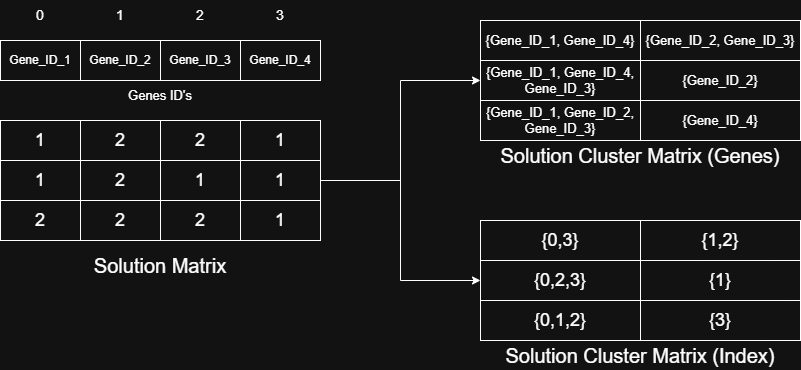

In [7]:
# Build the solution cluster matrix
scm_sets = solution_cluster_matrix.solution_cluster_matrix(
    Solution_Matrix, 
    genes_symbols, 
    mode="sets", 
    parallel=True, 
    max_workers=4
)

scm_index = solution_cluster_matrix.solution_cluster_matrix(
    Solution_Matrix, 
    genes_symbols, 
    mode="indices", 
    parallel=True, 
    max_workers=4
)

# Example: structure of sol_clus_matrix for a single solution.
# sol_clus_matrix is a list with one entry per solution; each entry is a list of
# clusters, and each cluster is a set of gene symbols belonging to that group.
example_solution_sets = scm_sets[0]
example_solution_index = scm_index[0]

print(f"Number of solutions: {len(scm_sets)}")
print(f"Solution #0 has {len(example_solution_sets)} clusters:")
for cluster_id, cluster_genes in enumerate(example_solution_sets):
    sample = sorted(cluster_genes)[:5]
    print(f"  Cluster {cluster_id}: {len(cluster_genes)} genes, e.g. {sample}")
print("\n", end="")
print(f"Number of solutions: {len(scm_index)}")
print(f"Solution #0 has {len(example_solution_index)} clusters:")
for cluster_id, cluster_genes in enumerate(example_solution_index):
    sample = sorted(cluster_genes)[:5]
    print(f"  Cluster {cluster_id}: {len(cluster_genes)} genes, e.g. {sample}")


Number of solutions: 116
Solution #0 has 4 clusters:
  Cluster 0: 137 genes, e.g. ['AGPAT3', 'AK3', 'AMDHD2', 'ARID1A', 'ARID1B']
  Cluster 1: 156 genes, e.g. ['ACTG1', 'ACVRL1', 'ADAMTS2', 'AGGF1', 'AKAP12']
  Cluster 2: 120 genes, e.g. ['ABCA7', 'ABHD12', 'ABHD4', 'AGAP3', 'ALG13']
  Cluster 3: 87 genes, e.g. ['ABCG8', 'ACACA', 'AIG1', 'AP2A1', 'BAG3']

Number of solutions: 116
Solution #0 has 4 clusters:
  Cluster 0: 156 genes, e.g. [np.int32(0), np.int32(2), np.int32(7), np.int32(8), np.int32(9)]
  Cluster 1: 120 genes, e.g. [np.int32(1), np.int32(4), np.int32(6), np.int32(13), np.int32(15)]
  Cluster 2: 87 genes, e.g. [np.int32(3), np.int32(5), np.int32(10), np.int32(27), np.int32(29)]
  Cluster 3: 137 genes, e.g. [np.int32(12), np.int32(14), np.int32(17), np.int32(21), np.int32(28)]


## GO Semantic Similarities

<div style="text-align: justify">
Building on the mapped gene identifiers and clustering solutions, this stage computes **biological similarity** between genes and, from there, between clustering solutions using **Gene Ontology semantic similarity**, powered by the `GO3` library. GO3 is a library released in 2025 aimed at providing functions for analyzing a species' gene set using data from files available in Gene Ontology (GO), primarily .gaf (Gene Annotation Format) files. One of its key strengths is the efficiency gained from its Rust-based core, wrapped with a Python-compatible interface, allowing it to compute semantic distance matrices considerably faster than other existing Python libraries [14] [15]. Two equivalent approaches are provided to compute a full pairwise **gene similarity matrix**:

- **`compute_gene_similarity_matrix_go3`**: computes the matrix directly via GO3's native gene_distance_matrix routine, converting the resulting distances into similarities (similarity = 1 - distance). This is the more efficient path for large gene sets. However, this function has the drawback of requiring every gene identifier to be present in the GAF file supplied as input, forcing the researcher to manually review the source data (genes or annotations), which makes it sensitive to issues such as deprecated gene symbols.
- **`compute_gene_similarity_matrix_by_batch`**: computes similarity explicitly for each gene pair combination via compare_gene_pairs_batch, assembling the results into a symmetric matrix. This offers finer control at the cost of enumerating every pair. This function is intended for use in the web platform, since it does not suffer from the drawbacks associated with the previous one

Both require a **GO terms file** (`.obo`) and a **GAF annotation file**, and are configured through `GeneSimilarityOptions`:

- **`ontology`** — the GO namespace to use: `BP` (biological process), `MF` (molecular function), or `CC` (cellular component).
- **`measure`** — the pairwise term-similarity method. GO3 supports several families: IC-based methods (`resnik`, `lin`, `jc`, `simrel`, `iccoef`), the hybrid `graphic` and `topoicsim`, and the purely topological `wang` method, which weights ancestor contributions from the GO graph structure and does not require annotation-derived IC values — useful when annotations may be biased or incomplete.
- **`groupwise`** — the strategy used to aggregate term-level scores into a single gene-level score: `bma` (best match average, the most common default), `max` (strongest shared function), `avg` (mean over all pairs), `hausdorff` (worst-case best match, a conservative lower bound), or `simgic` (IC-weighted Jaccard over shared ancestor sets).
- **`distance_method`** — how similarity is converted into distance for downstream clustering (`auto`, `one_minus`, `max_minus`, `reciprocal`).
- **`num_threads_go3`** — number of threads used by GO3 internally (`0` = automatic).

See the [GO3 semantic similarity documentation](https://go3.readthedocs.io/en/latest/similarity.html) for full mathematical definitions and guidance on choosing a method.

Once a gene similarity matrix is available, **`solution_go_similarity_from_dataframe`** extends this information to the **solution level**. Given pairs of clusters (from different clustering solutions) listed in a reference DataFrame, it computes the average gene-level similarity between the two clusters and aggregates these values into a solution-by-solution similarity matrix, optionally normalized to `[0, 1]`.

### Gene Ontology

The Gene Ontology (GO) framework is a dynamic, controlled vocabulary organized into three independent and complementary domains: Biological Process (BP), describing the biological objectives to which a gene product contributes, such as DNA replication or signal transduction; Molecular Function (MF), defining the biochemical activity carried out by the gene product, such as kinase or transporter activity; and Cellular Component (CC), indicating the subcellular location where the gene product is active, such as the nucleus or ribosome. These three domains form directed acyclic graphs (DAGs) where terms are connected hierarchically, each term may have multiple parent terms, and annotations propagate upward following the True Path Rule, meaning that a gene annotated to a specific term is implicitly annotated to all its ancestors. This structure allows queries at varying levels of biological abstraction, from broad functional categories to highly specific terms, depending on the depth of available experimental evidence [12].

<div align="center">

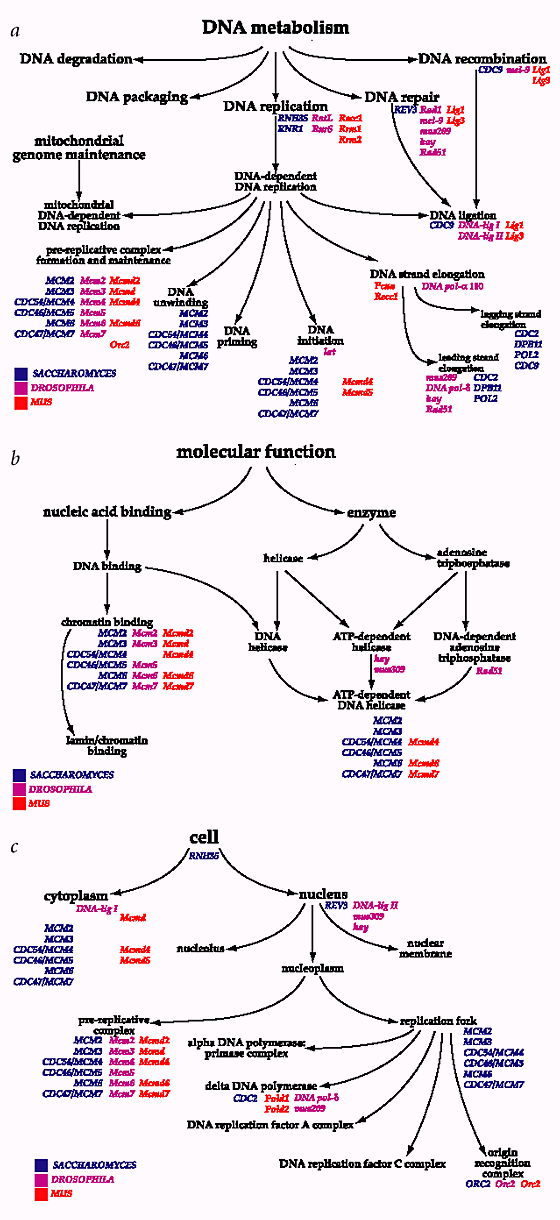
  <figcaption style="font-size: 0.9em; color: #FFF; margin-top: 8px; text-align: justify;">
    <strong>Figure 3.</strong> Example Diagram of Gene Ontology framework. <br>
  </figcaption>
</div>

**Semantic similarity** measures the degree of taxonomical resemblance between two concepts, producing a numerical score that estimates how related they are based on the semantic evidence observed in a knowledge source. The fundamental premise is that concepts occupying nearby positions in an ontological hierarchy, structured as a directed acyclic graph where nodes represent concepts and edges represent is-a or part-of relationships, share more meaning than distant ones.  

The key quantity underlying most similarity measures is the Information Content (IC) of a concept, defined as the inverse of its probability of appearance: **more specific, concrete concepts carry higher IC than broad, general ones**. Formally:

$IC(a)=−log⁡ p(a)$

This captures a core intuition: the more a concept specializes within a hierarchy, the more information it conveys. Two concepts are then compared through their Least Common Subsumer (LCS), referred to in Gene Ontology as the MICA, the most specific ancestor they share in the ontology. The greater the IC of the LCS, the more specific their shared meaning, and therefore the more similar they are.

### Functions

| Function | Description |
|---|---|
| `compute_gene_similarity_matrix_go3(genes, obo_path, gaf_path, go3_opts=GeneSimilarityOptions())` | Computes a full pairwise gene similarity matrix using GO3's native distance-matrix computation. Returns the ordered list of genes and the corresponding similarity matrix. |
| `compute_gene_similarity_matrix_by_batch(genes, obo_path, gaf_path, go3_opts=GeneSimilarityOptions())` | Computes a pairwise gene similarity matrix by explicitly scoring each gene pair in batch via GO3. Returns the ordered list of genes and the corresponding symmetric similarity matrix. |

</div>

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
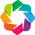

[clustered_heatmap_hv] Row clustering done (method=average, OLO=True).
[clustered_heatmap_hv] Column clustering done (method=average, OLO=True).


[clustered_heatmap_hv] HTML saved at: c:\Users\benja\Desktop\workspace\ItalianEdge\examples\results\gene_similarity_heatmap.html


In [8]:
# Build the biological similarity matrix. ontology/measure/groupwise select the GO
# semantic-similarity method (Wang, BMA-aggregated, Biological Process); distance_method
# controls how similarities are turned into distances; load_go_terms/num_threads_go3
# control go3 term loading and its internal thread count (0 = auto/default).
"""
Ontology            -> GO DAG to perform semantic calculus: "BP" (biological process), "MF" (molecular function), 
                       "CC" (cell component)
Groupwise           -> Groupwise method to calculate metric for genes: "bma" (best-match average), 
                       "max" (max value), "avg" (average), "hausdorff", "simgic".
SimilarityMeasure   -> Semantic similarity metric: "resnik", "lin", "jc", "simrel", "iccoef", "graphic", 
                       "wang", "topoicsim"
DistanceTransform   -> Only for compute_gene_similarity_matrix_go3: "auto", "one_minus", "max_minus", 
                       "reciprocal"
load_go_terms       -> GO3 needs to load the ontology file
num_threads_go3     -> Threads of CPU needed to do calculus.
"""
option = gene_similarity.GeneSimilarityOptions(
    ontology="BP",
    measure="wang",
    groupwise="bma",
    distance_method="auto",
    load_go_terms=True,
    num_threads_go3=0,
)
_, wang_sim_matrix = gene_similarity.compute_gene_similarity_matrix_by_batch(genes_symbols,
    obo_path=obo_path,
    gaf_path=gaf_path,
    go3_opts=option
)


actions.save_matrix(wang_sim_matrix, RESULTS_DIR / "gene_similarity_matrix.npy")
heatmaps.plot_clustered_heatmap(
    wang_sim_matrix,
    labels=genes_symbols,
    clustering=heatmaps.ClusteringOptions(linkage_method="average", optimal_leaf_order=True),
    save_filepath=str(RESULTS_DIR / "gene_similarity_heatmap.html"),
    return_fig=False
)

## Consensus Clustering

<div style="text-align: justify">

With the gene and solution-level similarity matrices computed, the next step is the construction
of what is referred to as the **consensus solution**, a representative partition associated with
the entire set of clustering solutions. Following the framework introduced by Monti et al. (2003),
the consensus matrix **M** is formally defined as [17]:

$$M(i,j) = \frac{\sum_h M^{(h)}(i,j)}{\sum_h I^{(h)}(i,j)}$$

where $M^{(h)}(i,j) = 1$ if items $i$ and $j$ are assigned to the same cluster in run $h$
and 0 otherwise, and $I^{(h)}(i,j) = 1$ if both items are present in the $h$-th resampled
dataset. Each entry of **M** therefore records the proportion of runs in which two items
co-cluster, producing a symmetric similarity matrix with values in $[0, 1]$. Perfect
consensus corresponds to a block-diagonal matrix of 0s and 1s, where each block
represents a stable cluster [17].

From this matrix, a distance matrix $D = 1 - M$ is derived and used as input for
**hierarchical agglomerative clustering (HAC)**. Although Monti et al. (2003) employed
average linkage in the inner loop, the pipeline presented here evaluates all linkage methods
available in SciPy's `linkage` function [19], allowing the user to select
the most appropriate one based on the **cophenetic correlation coefficient** (Sokal & Rohlf,
1962). This coefficient measures how faithfully the dendrogram preserves the original
pairwise distances between items, and is defined as [18] [20]:

$$c = \frac{\sum_{i<j}(d_{ij} - \bar{d})(t_{ij} - \bar{t})}
           {\sqrt{\sum_{i<j}(d_{ij} - \bar{d})^2 \cdot \sum_{i<j}(t_{ij} - \bar{t})^2}}$$

where $d_{ij}$ is the original distance between items $i$ and $j$, $t_{ij}$ is the
cophenetic distance (the height at which they are first joined in the dendrogram),
and $\bar{d}$, $\bar{t}$ are their respective means. Values above 0.75 indicate
a strong correspondence between the distance structure and the dendrogram topology
[18] [19] [20].

The available linkage methods differ in how the distance between two clusters is defined
at each merge step [18]:

| Method | Distance definition | Behavior |
|---|---|---|
| **Single** | Minimum distance between any two points across clusters | Tends to produce elongated, chained clusters; sensitive to outliers |
| **Complete** | Maximum distance between any two points across clusters | Produces compact, roughly equal-sized clusters; sensitive to outliers |
| **Average** (UPGMA) | Mean of all pairwise distances between clusters | Balanced compromise; good general-purpose choice |
| **Weighted** (WPGMA) | Like average but gives equal weight to each cluster regardless of size | Useful when cluster sizes are very unequal |
| **Centroid** (UPGMC) | Distance between cluster centroids | Can produce inversions in the dendrogram |
| **Median** (WPGMC) | Median-based centroid; weighted version of centroid | Also prone to inversions; robust to outliers |
| **Ward** | Minimises the total within-cluster variance at each merge | Tends to produce compact, spherical clusters of similar size; generally optimal for gene expression data |

The full workflow is implemented in `he_clustering`, which wraps hierarchical clustering
with optional interactive Plotly dendrogram visualization (configurable via `DendrogramOptions`),
HTML export (via `ExportOptions`), and returns cluster labels alongside the figure object
and/or HTML string as requested.


### Functions

| Function | Description |
|---|---|
| `compute_hierarchical_clustering(distance_matrix, genes, options=ClusteringOptions())` | Performs hierarchical clustering on a precomputed distance matrix and cuts it into a fixed number of clusters (`num_groups`). Returns the linkage matrix `Z`, the cluster labels per gene, and the cophenetic correlation coefficient. |
| `he_clustering(distance_matrix, genes, clustering=ClusteringOptions(), dendrogram_opts=DendrogramOptions(), save_html_to=None, export=ExportOptions(), return_fig=False, return_html=False)` | High-level interface that computes hierarchical clustering and, optionally, builds and/or exports an interactive Plotly dendrogram to HTML. Returns cluster labels by default, and additionally the figure and/or HTML string depending on the requested flags. |
| `consensus_matrix(Solutions_Matrix)` | Computes a coincidence and consensus matrix from multiple clustering solutions (e.g., repeated runs or bootstrap replicates). Given a matrix of cluster labels of shape `(n_solutions, n_genes)`, returns the coincidence matrix (proportion of solutions in which each pair of genes is assigned to the same cluster) and the consensus matrix, defined as `1 − coincidence`, which can be used as a distance matrix for downstream clustering. |

</div>

In [9]:
# Calculus of the consensus matrix.
cons_matrix, dist_matrix = consensus_matrix.consensus_matrix(Solution_Matrix)
actions.save_matrix(cons_matrix, RESULTS_DIR / "consensus_matrix.npy")
actions.save_matrix(dist_matrix, RESULTS_DIR / "distance_matrix.npy")
print(f"Consensus matrix: shape={cons_matrix.shape}, dtype={cons_matrix.dtype}")
print(f"Distance matrix (1 - consensus): shape={dist_matrix.shape}, dtype={dist_matrix.dtype}")

# Options for hierarchical clustering.
"""
num_groups      -> number of groups as result.
method          -> Method for dendrogram construction: "single", "complete", "average", "weighted", 
                   "centroid", "median", "ward"
sym_tol         -> tolerance value to establish similarity between elements.
"""
options_hierarchical = {
    "single":   he_clustering.ClusteringOptions(num_groups=4, method="single",   sym_tol=1e-6),
    "complete": he_clustering.ClusteringOptions(num_groups=4, method="complete", sym_tol=1e-6),
    "average":  he_clustering.ClusteringOptions(num_groups=4, method="average",  sym_tol=1e-6),
    "weighted": he_clustering.ClusteringOptions(num_groups=4, method="weighted", sym_tol=1e-6),
    "centroid": he_clustering.ClusteringOptions(num_groups=4, method="centroid", sym_tol=1e-6),
    "median":   he_clustering.ClusteringOptions(num_groups=4, method="median",   sym_tol=1e-6),
    "ward":     he_clustering.ClusteringOptions(num_groups=4, method="ward",     sym_tol=1e-6),
}

# save_html_to=None skips writing dendrogram HTML files to disk; return_fig=True
# gives back the Plotly figure so it can be rendered inline instead.
consensus_arrays: list[np.ndarray] = []
for key, option in options_hierarchical.items():
    hierarchical_solution = he_clustering.he_clustering(
        dist_matrix, 
        genes_symbols, 
        option,
        save_html_to=str(RESULTS_DIR / f"dendrogram_{key}.html"), 
        return_fig=False
    )
    consensus_arrays.append(hierarchical_solution)

# Compare cluster-size proportions across linkage methods in a single aligned table
# instead of one pprint per method, so differences are easy to scan at a glance.
n_genes = dist_matrix.shape[0]
proportions = {}
for method, array in zip(options_hierarchical, consensus_arrays):
    uniq, counts = np.unique(array, return_counts=True)
    proportions[method] = pd.Series(counts, index=uniq)
proportions_df = pd.DataFrame(proportions)
proportions_df = (proportions_df / n_genes * 100).round(1)
proportions_df.index.name = "cluster"
print("Cluster-size proportions (%) per linkage method:")
display(proportions_df)
actions.save_dataframe(proportions_df.reset_index(), RESULTS_DIR / "cluster_size_proportions.csv")
print("Methods disagree on cluster composition, so a criterion is needed to pick one.")

# Study of the groups from a chosen consensus solution (index 4 == "centroid")
consensus_matrix_stack = np.array(consensus_arrays)
print(f"Consensus solutions stack: shape={consensus_matrix_stack.shape}, dtype={consensus_matrix_stack.dtype}")
clusters = solution_cluster_matrix.solution_cluster_matrix(consensus_matrix_stack, genes_symbols, parallel=False)

chosen_method = list(options_hierarchical)[4]  # matches clusters[4] and the "index 4 == centroid" note above
print(f"Clusters for method '{chosen_method}':")
for cluster_id, cluster_genes in enumerate(clusters[4]):
    sample = sorted(cluster_genes)[:5]
    print(f"  Cluster {cluster_id}: {len(cluster_genes)} genes, e.g. {sample}")


Consensus matrix: shape=(500, 500), dtype=float64
Distance matrix (1 - consensus): shape=(500, 500), dtype=float64
Cophenetic correlation coefficient: 0.6267 (moderate clustering structure)
[he_clustering] Dendrogram HTML saved at: c:\Users\benja\Desktop\workspace\ItalianEdge\examples\results\dendrogram_single.html
Cophenetic correlation coefficient: 0.7812 (strong clustering structure)
[he_clustering] Dendrogram HTML saved at: c:\Users\benja\Desktop\workspace\ItalianEdge\examples\results\dendrogram_complete.html
Cophenetic correlation coefficient: 0.8963 (strong clustering structure)
[he_clustering] Dendrogram HTML saved at: c:\Users\benja\Desktop\workspace\ItalianEdge\examples\results\dendrogram_average.html
Cophenetic correlation coefficient: 0.8390 (strong clustering structure)
[he_clustering] Dendrogram HTML saved at: c:\Users\benja\Desktop\workspace\ItalianEdge\examples\results\dendrogram_weighted.html
Cophenetic correlation coefficient: 0.8936 (strong clustering structure)
[he_c

,single,complete,average,weighted,centroid,median,ward
cluster,,,,,,,
1,99.4,100.0,24.0,27.0,22.6,79.2,39.2
2,0.2,NaN,38.2,21.0,37.8,20.4,21.2
3,0.2,NaN,23.4,13.0,23.0,0.2,16.2
4,0.2,NaN,14.4,39.0,16.6,0.2,23.4


Methods disagree on cluster composition, so a criterion is needed to pick one.
Consensus solutions stack: shape=(7, 500), dtype=int32
Clusters for method 'centroid':
  Cluster 0: 113 genes, e.g. ['AMDHD2', 'ARID1A', 'ARID1B', 'ARID5B', 'B3GNT9']
  Cluster 1: 189 genes, e.g. ['ABHD4', 'ACACA', 'ACTG1', 'AGGF1', 'AIG1']
  Cluster 2: 115 genes, e.g. ['ABCA7', 'ABHD12', 'ACVRL1', 'ADAMTS2', 'AGAP3']
  Cluster 3: 83 genes, e.g. ['ABCG8', 'AKAP12', 'AKAP5', 'AMMECR1', 'ATAD1']


## GO Enrichment and Graphs for Analysis

<div style="text-align: justify">

With a consensus solution already built and selected according to the cophenetic correlation coefficient, we now have an ideal scenario to showcase the capabilities of the genetic study tools. This section presents the tools that are useful for analyzing gene clusters.

### Enrichment

Given a set of Entrez IDs, GO enrichment identifies GO terms that are statistically overrepresented in that gene set, via g:Profiler. Enrichment queries are always sent as a single batch (never chunked), since splitting them would distort statistical significance and multiple-testing correction [19]. A separate, chunkable and parallelizable function maps genes directly to their associated GO terms (annotation), which is used as input by the visualization functions below. Both are configured through dedicated options dataclasses (`GoEnrichmentOptions`, `AnnotationOptions`) controlling organism, GO sources/namespaces, significance threshold, and retry/backoff behavior.

| Module | Function | Description |
|---|---|---|
| Enrichment | `go_enrichment(entrez_ids, options=GoEnrichmentOptions())` | Performs GO enrichment analysis on a gene set via g:Profiler (single, unchunked query). Returns a DataFrame of enriched terms sorted by significance, optionally including gene ratio and q-score. |
| Enrichment | `annotation_from_entrez_ids(entrez_ids, options=AnnotationOptions())` | Maps genes to their associated GO terms using chunked, parallelized g:Profiler queries. Returns a dictionary mapping each GO term to its list of associated genes. |

### Visualization

Four complementary visual representations of enrichment/annotation results are available:

- **Ranked metric plots**: interactive scatter (gene ratio vs. term, sized/colored by
  significance) or bar charts (q-score), for quickly surveying top enriched terms.
  Two metrics drive these visualizations:

  - **Gene Ratio**: the proportion of input genes associated with each enriched term,
    defined as [21]:

    $$\text{Gene Ratio} = \frac{\text{Amount of genes associated to term} (k)}{\text{Total amount of genes} (n)}$$

    A higher Gene Ratio indicates that a larger fraction of the input gene list is
    captured by that term, reflecting stronger biological relevance of the annotation
    within the query set [21].

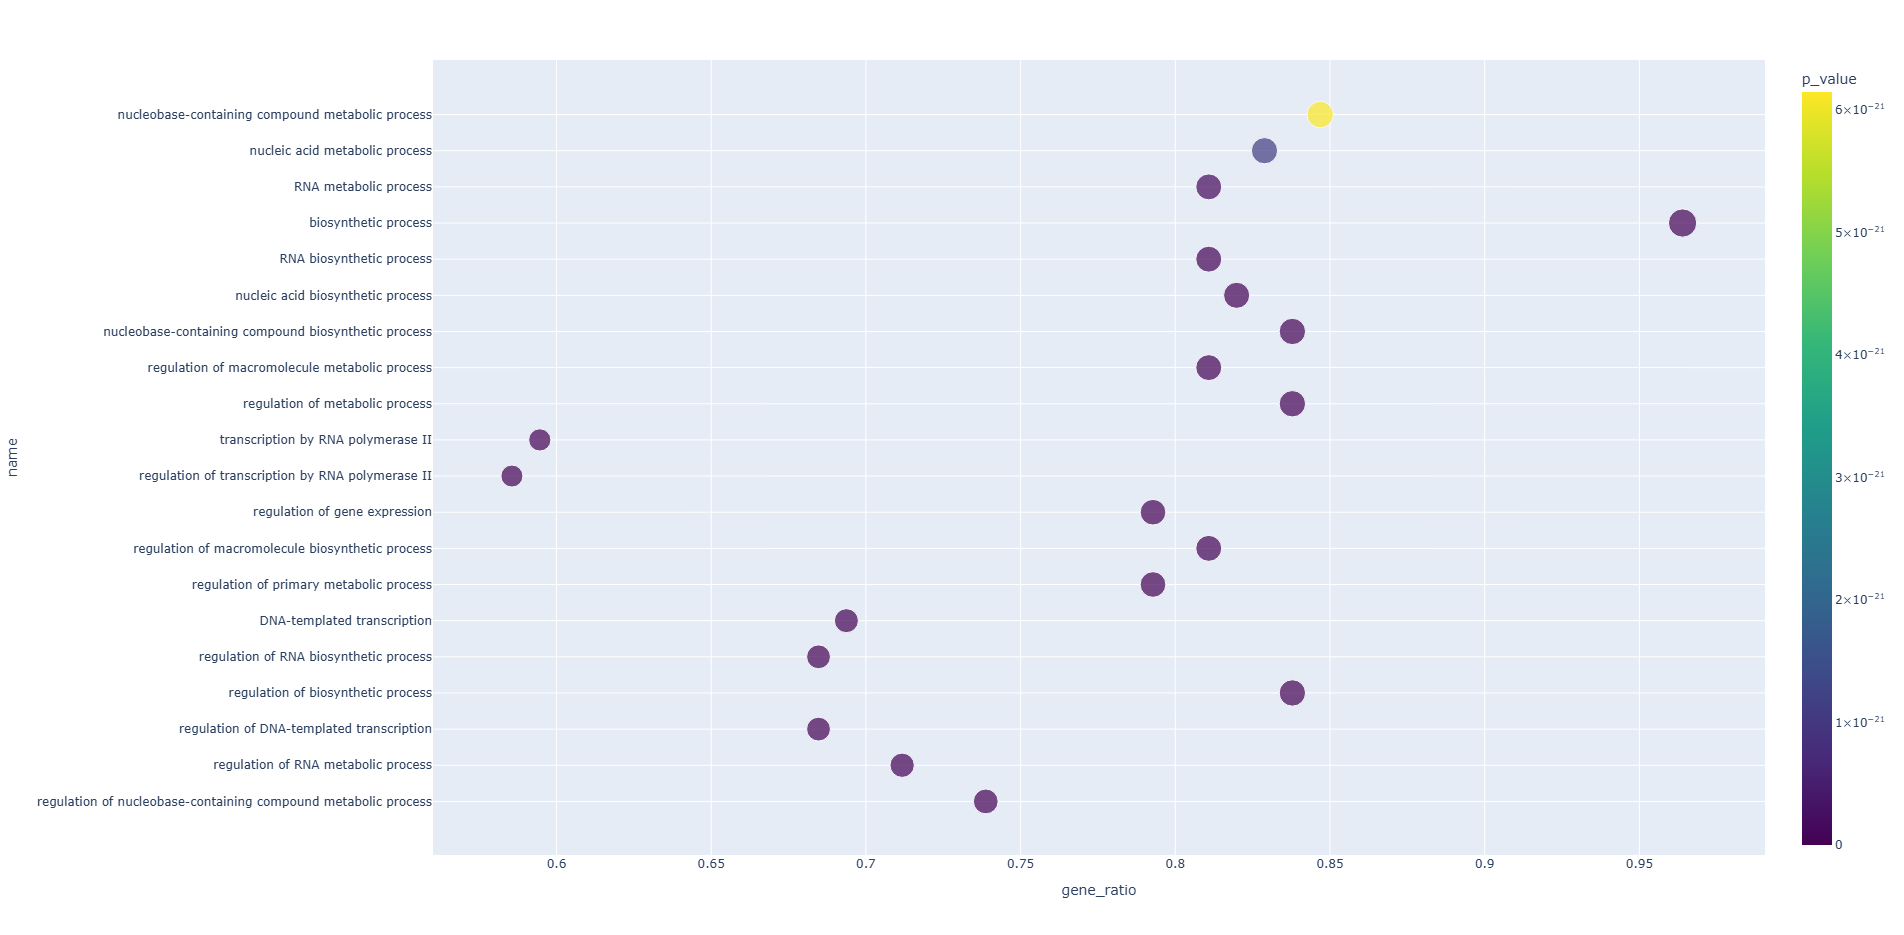
<figcaption style="font-size: 0.9em; color: #FFF; margin-top: 8px; text-align: justify;">
    <strong>Figure 4.</strong> Gene Ratio example. As shown, the graph displays the significance level, while dot size reflects the number of genes associated with each term. <br>
</figcaption>

  - **Q score**: a log-transformed representation of statistical significance, defined as:

    $$\text{Q score} = -\log_{10}(\text{adjusted } p\text{-value})$$

    By expressing the multiple-testing-corrected p-value on a positive ascending scale,
    the Q score makes it straightforward to rank and visually compare terms by their
    significance — larger values correspond to stronger enrichment signals (Yu, n.d.).
    The adjusted p-value itself is obtained via the cumulative hypergeometric test, which
    assesses whether a GO term is associated with the input gene set more frequently than
    expected by chance (Raudvere et al., 2019).

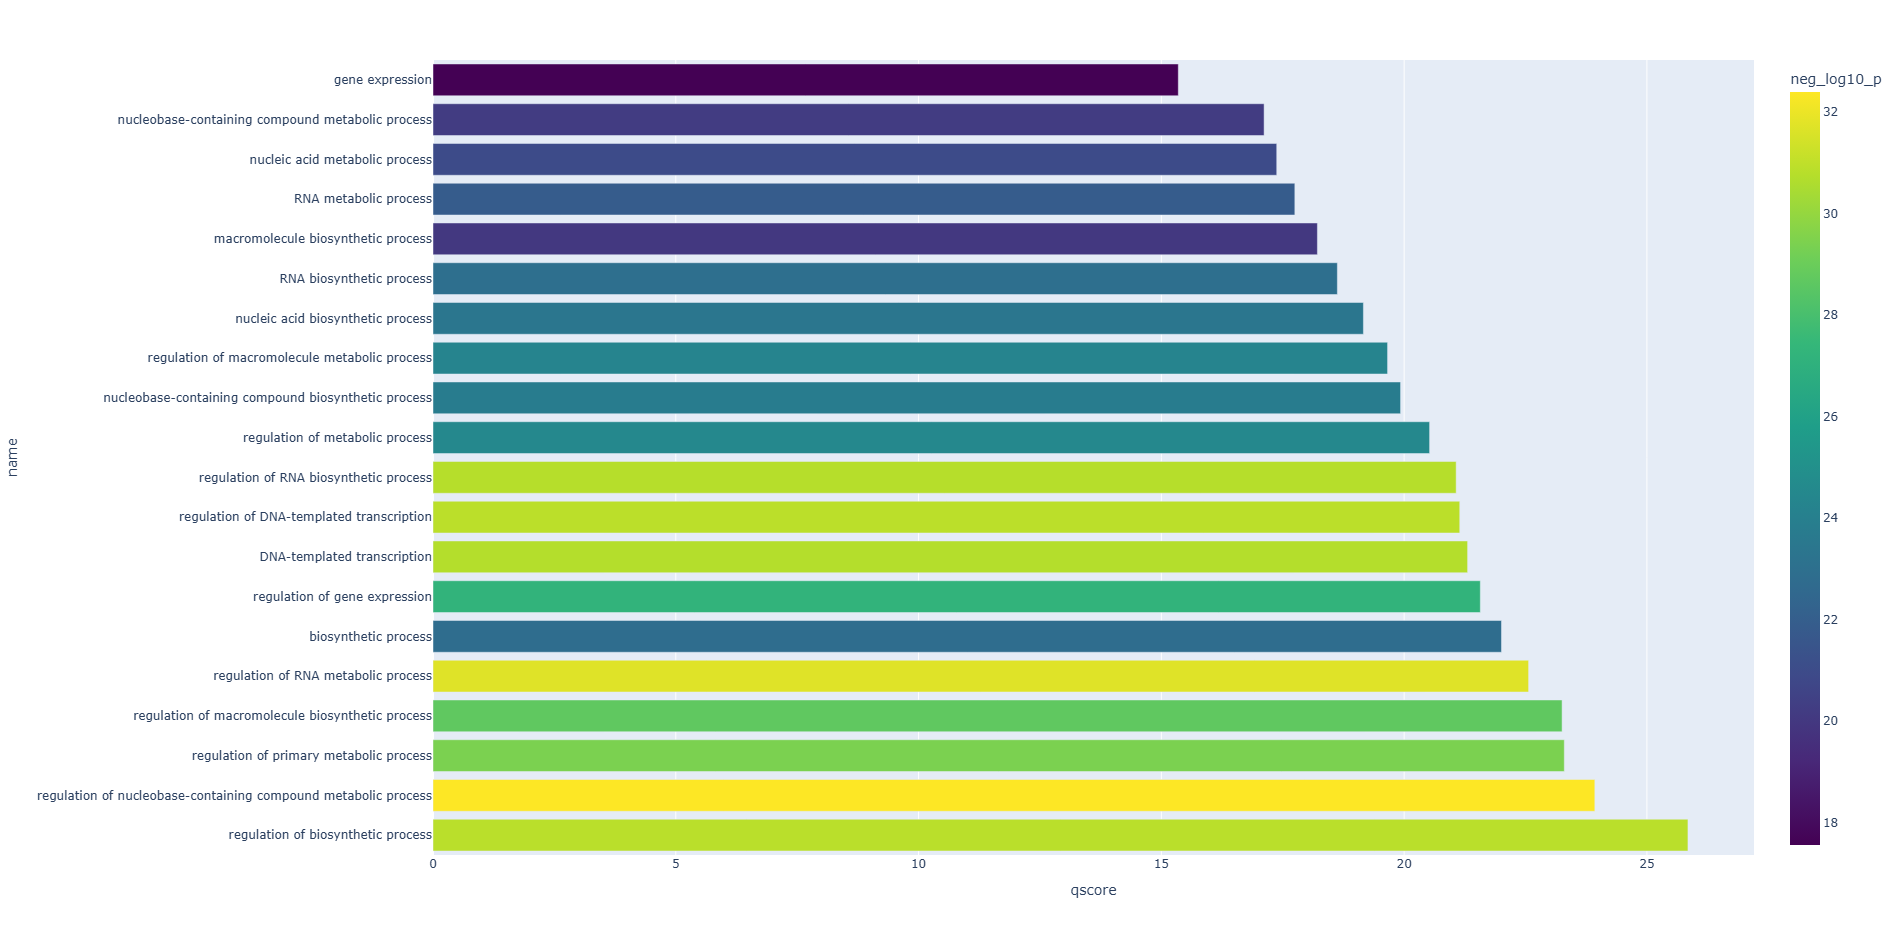
<figcaption style="font-size: 0.9em; color: #FFF; margin-top: 8px; text-align: justify;">
    <strong>Figure 5.</strong> Q-Ratio graph example. <br>
</figcaption>

- **GO similarity network**: a force-directed graph where nodes are GO terms (sized by gene count, colored by p-value) and edges connect terms whose GO semantic similarity (Wang index) exceeds a user-defined threshold. By default the term universe is restricted to the terms returned by enrichment (`restrict_to_enriched=True`), and an optional `significance_threshold` can further drop terms whose p-value exceeds a chosen cutoff. To draw this network, two layout algorithms provided by the networkx library can be used: spring (based on attraction–repulsion forces) and Kamada–Kawai (based on minimizing edge crossings).

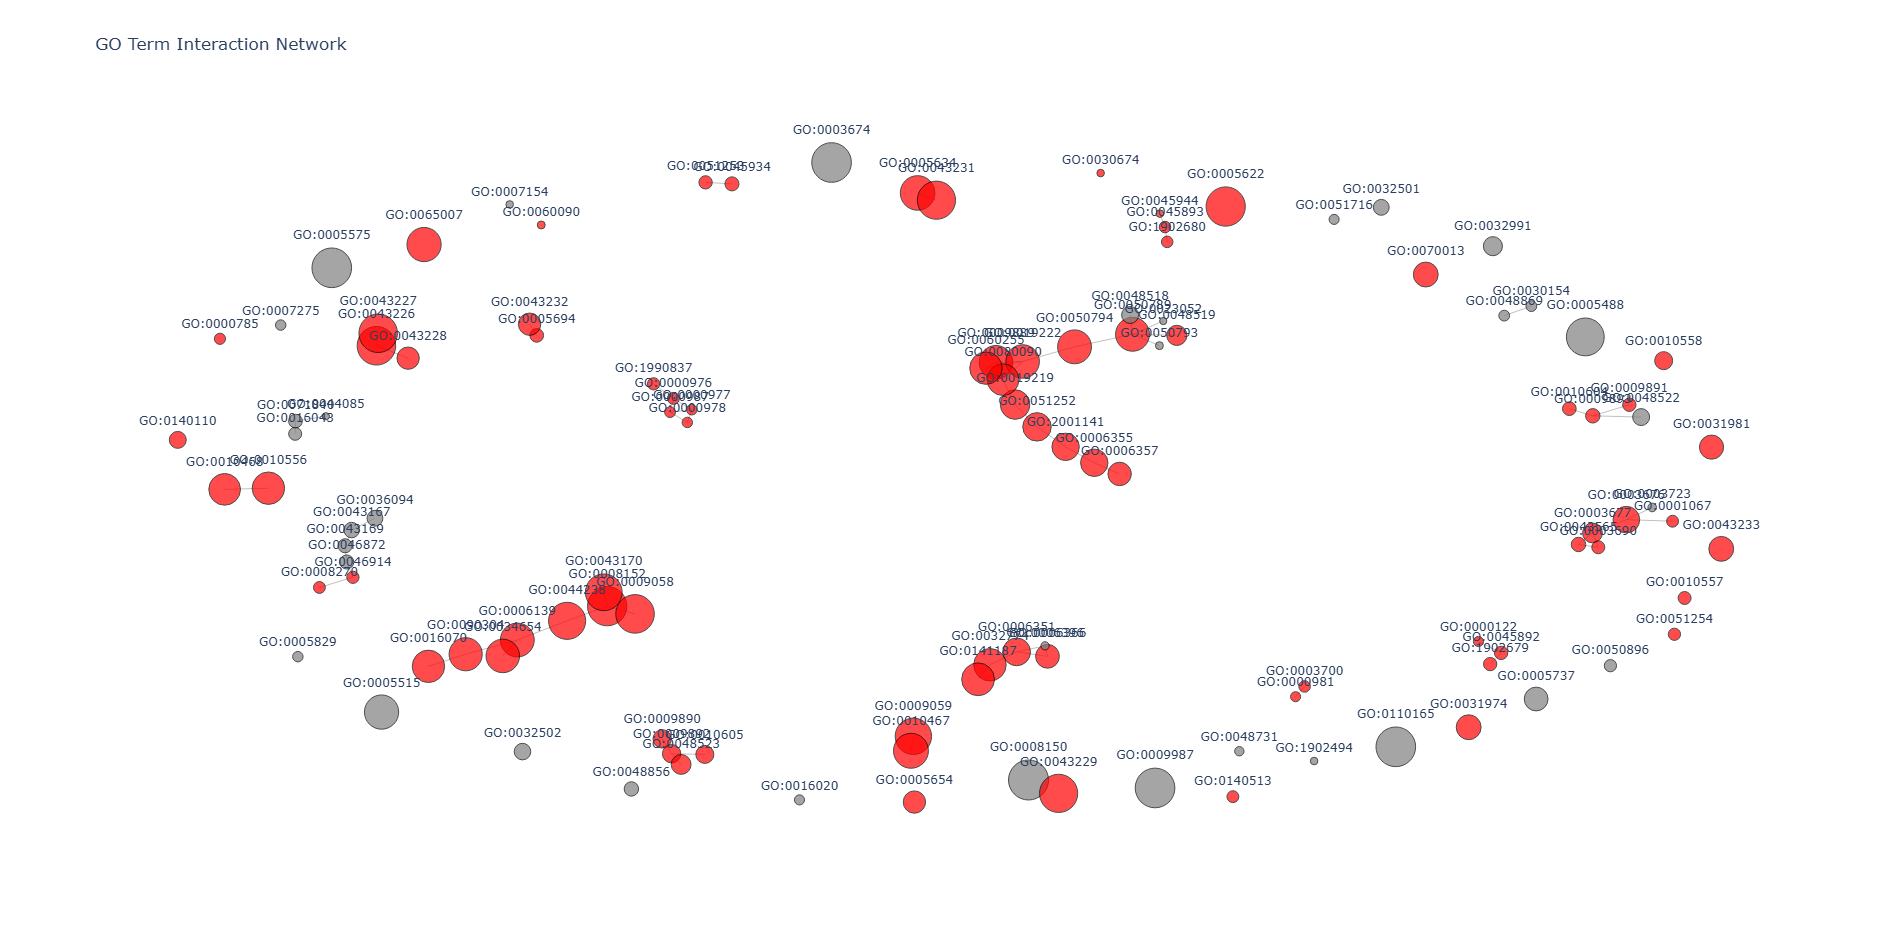
<figcaption style="font-size: 0.9em; color: #FFF; margin-top: 8px; text-align: justify;">
    <strong>Figure 6.</strong> Go network example. <br>
</figcaption>


- **Hierarchical GO DAG**: a layered, level-by-level visualization of the GO directed acyclic graph (using `goatools`), including ancestor terms to preserve hierarchical structure, with interactive click-to-highlight ancestor/descendant paths and colorbar by significance. As with the similarity network, target terms are restricted to enriched terms by default (`restrict_to_enriched=True`), with an optional `significance_threshold` for stricter filtering; ancestors added afterwards for structural context are not subject to this filter.

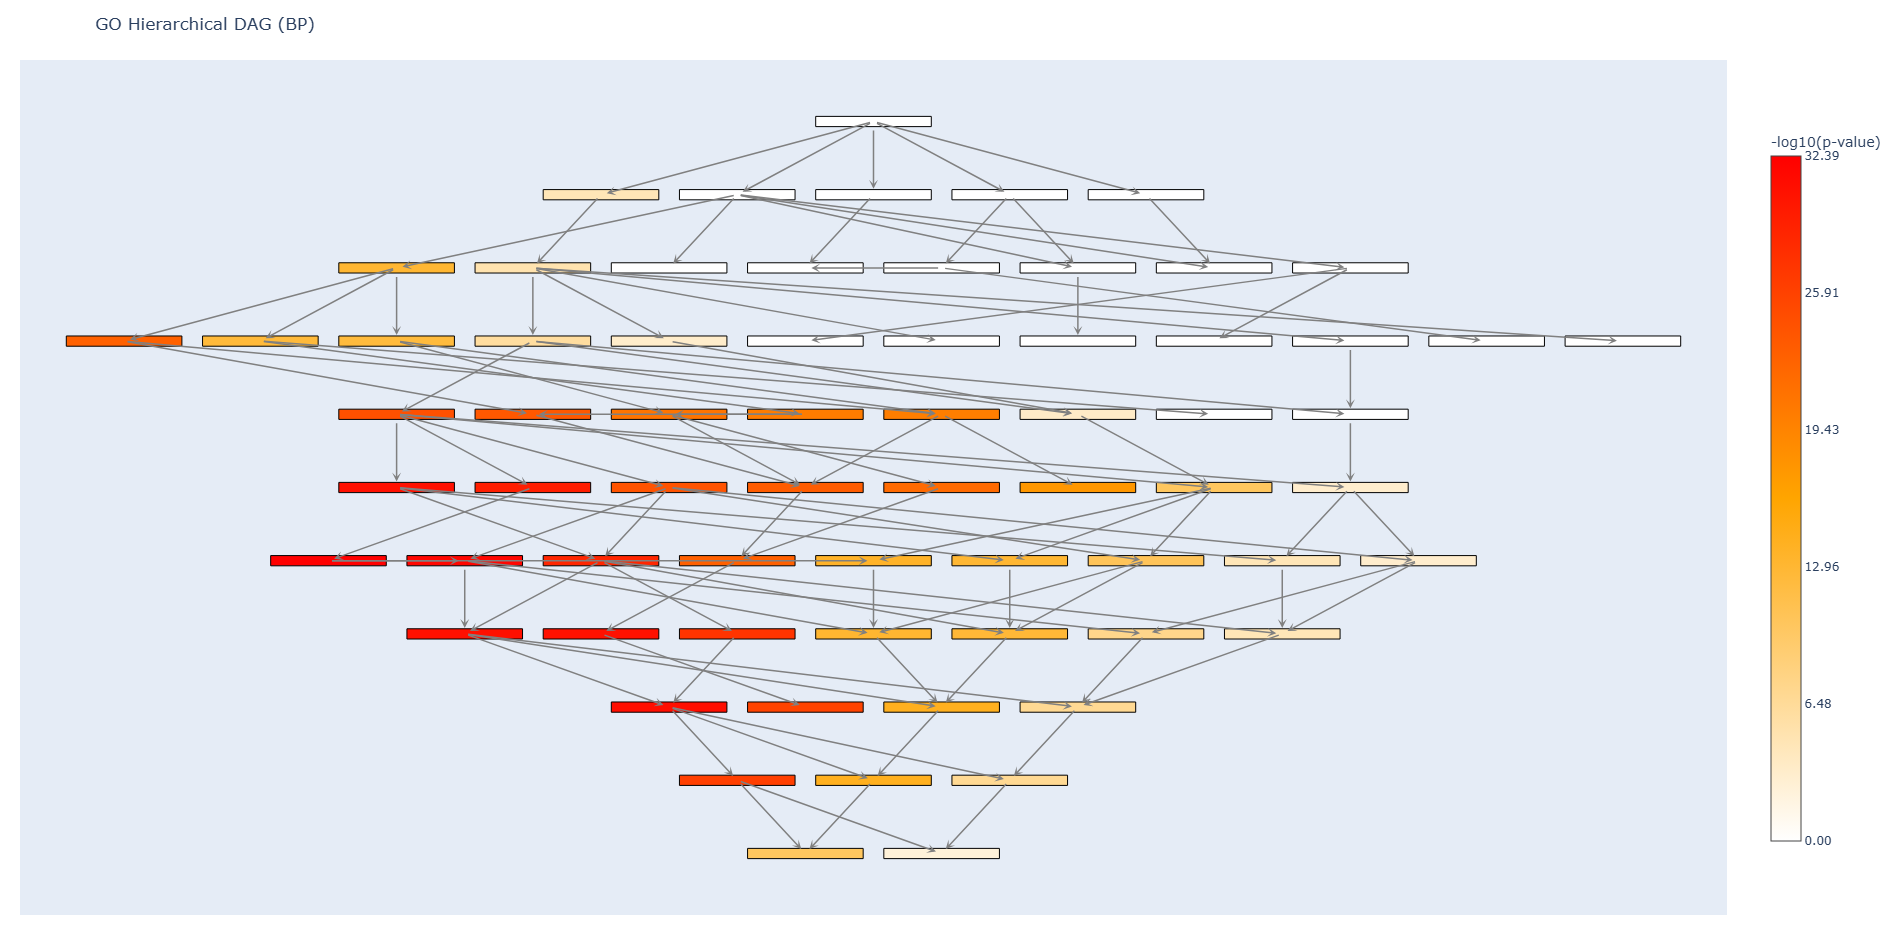
<figcaption style="font-size: 0.9em; color: #FFF; margin-top: 8px; text-align: justify;">
    <strong>Figure 7.</strong> Go dag example. <br>
</figcaption>


All visualizations can return a Plotly figure object, an HTML string, and/or save directly to an HTML file.

### Functions

| Module | Function | Description |
|---|---|---|
| Plots | `plot_go_metric(df, metric, save_path=None, options=GOPlotOptions(), return_fig=False, return_html=False)` | Generates an interactive plot of enrichment results for a chosen metric (`"gene_ratio"` scatter or `"qscore"` bar chart). Can save to HTML and/or return the figure/HTML. |
| Plots | `plot_gene_ratio(*args, **kwargs)` | Convenience wrapper around `plot_go_metric` fixed to the `"gene_ratio"` metric. |
| Plots | `plot_qscore(*args, **kwargs)` | Convenience wrapper around `plot_go_metric` fixed to the `"qscore"` metric. |
| Network | `plot_go_interaction_network_html(gene2terms, term_pvalues, gaf_path, obo_path, options=GoNetworkOptions(), save_html_to=None, return_fig=False, return_html=False)` | Builds a GO term similarity network (nodes = terms, edges = GO3 Wang similarity above a threshold) and renders it as an interactive Plotly graph. Returns the figure and/or HTML as requested. |
| Hierarchical DAG | `plot_go_hierarchy_html(gene2terms_or_term2genes, term_pvalues, options=GoHierarchyOptions(), save_html_to="go_hierarchy.html", return_fig=False, return_html=False)` | Builds a layered, level-by-level GO DAG visualization for a given ontology (BP/MF/CC), including ancestor terms, with interactive click-to-highlight paths. Returns the figure and/or HTML as requested. |
| Hierarchical DAG | `download_go_obo(obo_path="go.obo", force_download=False)` | Downloads the GO ontology file (`go.obo`) required by `plot_go_hierarchy_html`, unless it already exists locally. Returns the path to the OBO file. |

</div>

In [10]:
# --------------------------------------------------------
# CONFIGURATIONS
# --------------------------------------------------------

# GO enrichment configuration: organism/sources select the species and ontology
# namespaces queried, user_threshold is the significance cutoff, compute_gene_ratio/
# compute_qscore add derived columns, sort_by controls result ordering.
enrichment_options = go_enbrichment.GoEnrichmentOptions(
    organism="hsapiens",
    sources=("GO:BP", "GO:CC", "GO:MF"),
    user_threshold=0.05,
    include_evidences=False,
    request_retries=3,
    backoff_base_seconds=0.6,
    compute_gene_ratio=True,
    compute_qscore=True,
    sort_by="p_value",
)

# Annotation configuration: which ontologies to fetch per gene, and query batching.
annotation_options = go_enbrichment.AnnotationOptions(
    organism="hsapiens",
    sources=("GO:BP", "GO:CC", "GO:MF"),
    chunk_size=500,
    n_threads=4,
    request_retries=3,
    backoff_base_seconds=0.6,
)

# GO plot styling: colorscale/use_neglog10 control how p-values are rendered,
# top_n caps how many terms are shown.
go_plot_options = go_plots.GOPlotOptions(
    colorscale="Viridis",
    top_n=20,
    verbose=True,
    use_neglog10=True,
)

# Interaction-network layout: similarity_threshold controls which term pairs are
# linked, min_genes_per_term filters sparse terms, layout picks the graph algorithm.
# restrict_to_enriched keeps only terms present in term_pvalues (i.e. actually enriched),
# and significance_threshold (optional) drops terms above a chosen p-value cutoff.
network_options = go_network.GoNetworkOptions(
    similarity_threshold=0.7,
    min_genes_per_term=20,
    restrict_to_enriched=True,
    significance_threshold=None,
    max_node_size=40.0,
    layout="spring",
    random_state=42,
    verbose=False,
)

# Hierarchical DAG layout: max_terms/include_ancestors/max_total_nodes bound the
# graph size, the layout block spaces nodes, cmap_colors shades by significance.
# restrict_to_enriched/significance_threshold filter the target terms the same way
# as in the similarity network, before ancestors are added.
hierarchy_options = go_he_network.GoHierarchyOptions(
    ontology="BP",
    max_terms=120,
    min_genes_per_term=20,
    include_ancestors=True,
    max_total_nodes=600,
    restrict_to_enriched=True,
    significance_threshold=None,
    layer_gap_y=1.0,
    node_half_width=0.14,
    node_half_height=0.07,
    min_sep_x=0.05,
    title="GO Hierarchical DAG",
    cmap_colors=("#ffffff", "#ffa500", "#ff0000"),
    obo_path=str(obo_path),
    download_obo_if_missing=True,
    force_download_obo=False,
    verbose=True,
)

# --------------------------------------------------------
# PERFORM ENRICHMENT & ANNOTATIONS
# --------------------------------------------------------

group_dfs = [
    go_enbrichment.go_enrichment(list(clusters[4][i]), options=enrichment_options)
    for i in range(len(clusters[4]))
]

print(f"GO enrichment results for the '{chosen_method}' consensus solution ({len(group_dfs)} clusters):")
for group_id, df_group in enumerate(group_dfs):
    print(f"Cluster {group_id}: {len(df_group)} enriched terms")
    display(df_group.head(1))
    actions.save_dataframe(df_group, RESULTS_DIR / f"go_enrichment_cluster_{group_id}.csv")

group_annotations = [
    go_enbrichment.annotation_from_entrez_ids(list(clusters[4][i]), options=annotation_options)
    for i in range(len(clusters[4]))
]
for group_id, annotation in enumerate(group_annotations):
    n_terms = sum(len(terms) for terms in annotation.values())
    print(f"Cluster {group_id}: {len(annotation)} genes, {n_terms} GO term associations")
    summary = pd.Series(
        {gene: len(terms) for gene, terms in annotation.items()},
        name="n_go_terms",
    ).sort_values(ascending=False)
    display(summary.to_frame())


# --------------------------------------------------------
# PERFORM VISUALIZATIONS
# --------------------------------------------------------

# Focus the remaining plots on the first cluster as a worked example. For web development, it is mandatory to
# perform this analysis with all groups obtained.
df_grupo_1 = group_dfs[0]
anno_clus_1 = group_annotations[0]

# Gene ratio & Q-score.
go_plots.plot_gene_ratio(
    df_grupo_1, 
    save_path=str(RESULTS_DIR / "gene_ratio.html"), 
    options=go_plot_options
)
go_plots.plot_qscore(
    df_grupo_1, 
    save_path=str(RESULTS_DIR / "qscore.html"), 
    options=go_plot_options
)

# GO network.
term_pvalues = df_grupo_1.set_index("native")["p_value"].to_dict()
go_network.plot_go_interaction_network_html(
    anno_clus_1, 
    term_pvalues, 
    gaf_path=str(gaf_path), 
    obo_path=str(obo_path),
    options=network_options, 
    save_html_to=str(RESULTS_DIR / "go_similarity_network.html")
)

# GO DAG.
go_he_network.plot_go_hierarchy_html(
    anno_clus_1, 
    term_pvalues,
    options=hierarchy_options, 
    save_html_to=str(RESULTS_DIR / "go_hierarchy_dag.html")
)

GO enrichment results for the 'centroid' consensus solution (4 clusters):
Cluster 0: 87 enriched terms


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,gene_ratio,recall,query,parents,qscore
0,GO:BP,GO:0019219,regulation of nucleobase-containing compound m...,4.080231e-33,True,"""Any cellular process that modulates the frequ...",3954,111,82,20972,0.738739,0.020738,query_1,"[GO:0006139, GO:0080090]",23.927242


Cluster 1: 44 enriched terms


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,gene_ratio,recall,query,parents,qscore
0,GO:CC,GO:0005737,cytoplasm,1.572394e-16,True,"""The contents of a cell excluding the plasma m...",12601,185,161,22155,0.87027,0.012777,query_1,"[GO:0005622, GO:0110165]",13.753263


Cluster 2: 10 enriched terms


...

Cluster 2: 113 genes, 11979 GO term associations


,n_go_terms
SMAD3,628
ZC3H12A,546
DAB2IP,507
ACVRL1,341
PTPRS,338
...,...
DNAJC4,22
PPP2R2C,17
TMEM132B,5
FLYWCH2,4


Cluster 3: 82 genes, 9842 GO term associations


,n_go_terms
NRXN1,414
CD28,316
EFNA5,313
VIL1,260
HK2,256
...,...
ISYNA1,33
TP53I13,27
GPATCH2,25
AMMECR1,18


[GO] Loading OBO from: c:\Users\benja\Desktop\workspace\ItalianEdge\examples\resources\go.obo
c:\Users\benja\Desktop\workspace\ItalianEdge\examples\resources\go.obo: fmt(1.2) rel(2026-06-15) 41,535 Terms
[GO] Saved interactive hierarchy HTML at: c:\Users\benja\Desktop\workspace\ItalianEdge\examples\results\go_hierarchy_dag.html


## Solutions identification

<div style="text-align: justify">
Although the consensus solution provides a way to identify representative groups within the initial population of solutions, it is not the only valid analysis that can be performed on this set. To provide deeper insight, three additional approaches are offered:

- **Groups of similar solutions**: using similarity indices between clustering solutions (Jaccard index, Rand index, and Adjusted Rand index) that reveal similarities in composition, from which groups of solutions worth studying can be generated. Note that this relies on the inconsistency coefficient computed by the SciPy library; the concept behind this type of cut-off detection is based on the premise that very significant height variations within a dendrogram imply a natural position at which to split a group [22].

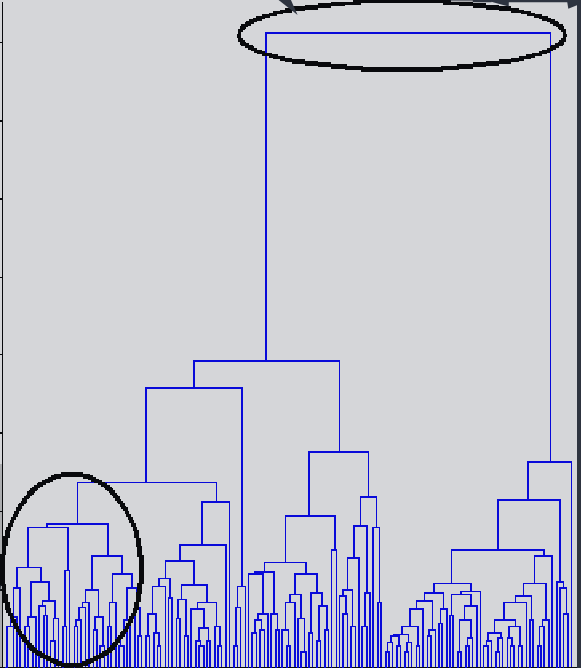
<figcaption style="font-size: 0.9em; color: #FFF; margin-top: 8px; text-align: justify;">
    <strong>Figure 8.</strong> Inconsistency concept. As shown in the figure, a natural group has a relatively small connection height among its members; however, when it presents a very abrupt jump relative to the average height of the previous connections, a natural cut point in the dendrogram can be inferred [22]. <br>
</figcaption>
</div>

- **Set of solutions distinct from the consensus**: since the consensus is a representative solution, identifying solutions that are significantly different from it via z-score (or a fixed top-K) can reveal a subset of solutions that diverge from the rest, using `compute_consensus_distance_scores` / `identify_outlier_solutions_vs_consensus` [23] [24].
- **Set of solutions with discrepancy**: by comparing the compositional (Jaccard) similarity against the biological (Wang) similarity of solutions, it is possible to identify solutions with a large discrepancy between the two, either biologically coherent but structurally different solutions, or structurally similar solutions that diverge biologically, and obtain a subset of solutions exhibiting that behavior, using `semantic_structural_discrepancy.py`.

## Functions

| Module | Function | Description |
|---|---|---|
| Similar solutions | `solution_go_similarity_from_dataframe(ids, gene_similarity_matrix, similarity_metric, reference_df, solutions, na_value="NA", normalize_matrix=True)` | Computes similarity between clustering solutions by averaging gene-level similarity across paired clusters listed in `reference_df`. Returns the solution similarity matrix and the updated DataFrame with the added similarity column. |
| Similar solutions | `compute_dynamic_clustering(distance_matrix, genes, options=DynamicClusteringOptions())` | Performs hierarchical clustering with automatic detection of the number of clusters, using a gap heuristic on the linkage matrix. Returns the linkage matrix `Z`, the cluster labels, the cophenetic correlation coefficient, and a ranked report of candidate cut points. |
| Distinct from consensus | `compute_consensus_distance_scores(distances_to_consensus, labels=None, solution_matrix=None)` | Builds a per-solution distance-to-consensus table with a z-score relative to the distribution of all distances. Returns a DataFrame sorted by distance descending. |
| Distinct from consensus | `identify_outlier_solutions_vs_consensus(distances_to_consensus, labels=None, solution_matrix=None, options=ConsensusDistanceOptions())` | Filters to the solutions significantly distant from the reference consensus solution, either the top-K most distant or those whose z-score is at or above `options.z_threshold`. |
| Distinct from consensus | `get_outlier_solution_indices(outliers_df)` | Returns the sorted list of solution indices flagged by `identify_outlier_solutions_vs_consensus`. |
| Distinct from consensus | `plot_consensus_distance_summary(scores_df, outliers_df, title=...)` | Two-panel interactive figure: a ranked bar chart of distances to consensus (outliers highlighted), and a histogram of the distance distribution with the outlier cutoff marked. |
| Discrepancy | `compute_discrepancy_matrix(wang_matrix, jaccard_matrix)` | Computes the element-wise discrepancy `Wang similarity − Jaccard similarity` between solutions, masking the diagonal. |
| Discrepancy | `compute_pairwise_discrepancy_profile(wang_matrix, jaccard_matrix, labels=None, options=DiscrepancyOptions())` | Per-pair summary of Wang-vs-Jaccard discrepancy — one row per solution pair, with a z-score for ranking (no per-solution aggregation). |
| Discrepancy | `identify_discrepant_solution_pairs(wang_matrix, jaccard_matrix, labels=None, options=DiscrepancyOptions())` | Filters solution PAIRS by z-score threshold or fixed top-K, in either direction (`wang_over_jaccard` or `jaccard_over_wang`). Returns both the full pairwise profile and the flagged-outlier subset. |
| Discrepancy | `plot_discrepancy_summary(wang_matrix, jaccard_matrix, outliers_df, title=...)` | Two-panel interactive figure: scatter of Wang vs. Jaccard similarity per pair (colored by discrepancy, flagged pairs highlighted), and a heatmap of the discrepancy matrix. |

</div>

In [11]:
# Labels needed to represent solutions in the heatmaps (one per solution).
labels = [str(i) for i in range(Solution_Matrix.shape[0])]

def average_matrices(matrix_a: np.ndarray, matrix_b: np.ndarray, method: str, weight_a: float = 0.5) -> np.ndarray:
    """
    Combine two similarity matrices into a single consensus matrix.

    Parameters
    ----------
    matrix_a, matrix_b : np.ndarray
        Square similarity matrices of the same shape (values in [0, 1]).
    method : {"arithmetic", "weighted", "geometric", "harmonic"}
        Averaging strategy.
    weight_a : float
        Weight given to matrix_a when method="weighted" (weight_b = 1 - weight_a).

    Returns
    -------
    np.ndarray
        Consensus similarity matrix.
    """
    if matrix_a.shape != matrix_b.shape:
        raise ValueError("matrix_a and matrix_b must have the same shape.")

    eps = 1e-12  # avoid division by zero in harmonic mean

    if method == "arithmetic":
        result = (matrix_a + matrix_b) / 2.0

    elif method == "weighted":
        if not (0.0 <= weight_a <= 1.0):
            raise ValueError("weight_a must be in [0, 1].")
        result = weight_a * matrix_a + (1.0 - weight_a) * matrix_b

    elif method == "geometric":
        result = np.sqrt(np.clip(matrix_a, 0, None) * np.clip(matrix_b, 0, None))

    elif method == "harmonic":
        result = 2.0 * matrix_a * matrix_b / (matrix_a + matrix_b + eps)

    else:
        raise ValueError("method must be 'arithmetic', 'weighted', 'geometric', or 'harmonic'.")

    np.fill_diagonal(result, 1.0)
    return result

The solution-associated matrix follows this format:
array([[1.        , 0.16323307, 0.20283096, ..., 0.23795705, 0.27176652,
        0.23935706],
       [0.16323307, 1.        , 0.58335055, ..., 0.41419314, 0.27545015,
        0.41956147],
       [0.20283096, 0.58335055, 1.        , ..., 0.5457207 , 0.3455726 ,
        0.5500745 ],
       ...,
       [0.23795705, 0.41419314, 0.5457207 , ..., 1.        , 0.38519116,
        0.76842476],
       [0.27176652, 0.27545015, 0.3455726 , ..., 0.38519116, 1.        ,
        0.39861452],
       [0.23935706, 0.41956147, 0.5500745 , ..., 0.76842476, 0.39861452,
        1.        ]], shape=(116, 116))


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
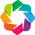

[clustered_heatmap_hv] Row clustering done (method=average, OLO=True).
[clustered_heatmap_hv] Column clustering done (method=average, OLO=True).


[clustered_heatmap_hv] HTML saved at: c:\Users\benja\Desktop\workspace\ItalianEdge\examples\results\clustered_similar.html
[inconsistency] Cophenetic correlation: 0.9138 (strong)
[inconsistency] Highest coefficient: 1.1408 -- cutting at height 0.696732 -> 2 clusters.
[inconsistency] Alternative cut points (ranked by coefficient):
  rank=2  k=5  coeff=1.1273  height=0.606589
  rank=3  k=7  coeff=1.1192  height=0.568008
  rank=4  k=3  coeff=0.8847  height=0.664879
[he_inconsistency_clustering] Figure HTML saved at: c:\Users\benja\Desktop\workspace\ItalianEdge\examples\results\detect_clusters.html (4 candidate(s) shown)
[5 1 1 1 3 2 2 1 1 1 1 3 3 5 1 1 3 1 1 1 3 3 1 1 3 3 3 1 3 3 2 1 5 4 2 2 3
 1 1 5 3 1 5 3 3 2 3 3 3 4 1 1 1 1 5 1 2 2 2 5 1 1 2 1 3 2 2 3 3 3 3 1 1 1
 4 1 2 3 1 1 2 2 3 3 2 1 1 1 1 1 1 1 1 3 3 2 1 2 1 1 1 1 1 1 2 2 2 1 1 2 1
 1 2 1 3 1]


In [12]:
# Compute the Jaccard similarity between solutions.
Jaccard_Matrix = jaccard_values.jaccard_index_solutions(Solution_Matrix)
print("The solution-associated matrix follows this format:")
pprint(Jaccard_Matrix)
actions.save_matrix(Jaccard_Matrix, RESULTS_DIR / "jaccard_matrix.npy")

heatmaps.plot_clustered_heatmap(
    Jaccard_Matrix,
    labels=labels,
    clustering=heatmaps.ClusteringOptions(linkage_method="average", optimal_leaf_order=True),
    save_filepath=str(RESULTS_DIR / "clustered_similar.html")
)

opt = he_clustering_inc.InconsistencyClusteringOptions(
    method = "average",
    depth = 2,
    n_candidates = 4,
    min_clusters = 2,
    max_clusters = 7,
    validate_distance = True,
    sym_tol = 1e-12,
    verbose = True
)

output = he_clustering_inc.he_inconsistency_clustering(
    1 - Jaccard_Matrix, 
    genes=labels,
    clustering = opt,
    selected_rank= 2,
    save_html_to=str(RESULTS_DIR / "detect_clusters.html"))
print(output)

In [13]:
# Obtaining equivalent clusters by using jaccard matrix.
jaccard_equivalents_df = jaccard_values.find_equivalent_clusters_jaccard(scm_sets)
display(jaccard_equivalents_df.head(5))

matrix_with_consensus = np.vstack((Solution_Matrix, consensus_arrays[4]))
Jaccard_matrix_with_consensus = jaccard_values.jaccard_index_solutions(matrix_with_consensus)
consensus_row_idx = matrix_with_consensus.shape[0] - 1  # last row = the appended consensus solution
pprint(Jaccard_matrix_with_consensus[consensus_row_idx])

df_distance = gos.compute_consensus_distance_scores(1 - Jaccard_matrix_with_consensus[consensus_row_idx])
display(df_distance.head(5))
df_outliers = gos.identify_outlier_solutions_vs_consensus(1 - Jaccard_matrix_with_consensus[consensus_row_idx])
display(df_outliers.head(5))
indexes = gos.get_outlier_solution_indices(df_outliers)
pprint(indexes)

fig = gos.plot_consensus_distance_summary(df_distance, df_outliers)
fig.show()

,Solution 1,Solution 2,Cluster 1,Cluster 2,Jaccard Similarity
0,0,1,2,0,0.244000
1,0,1,1,3,0.188776
2,0,1,0,1,0.188596
3,0,1,3,2,0.045198
4,0,2,0,1,0.480263


array([0.2541402 , 0.43503567, 0.58642635, 0.36920354, 0.46601008,
       0.42935028, 0.43754283, 0.70451965, 0.62203646, 0.62203646,
       0.59114595, 0.4244662 , 0.46096365, 0.34055146, 0.42267956,
       0.46746963, 0.4628976 , 0.68274443, 0.7541645 , 0.68274443,
       0.32564268, 0.37044602, 0.47039158, 0.43503567, 0.45044605,
       0.4027339 , 0.46761621, 0.43464092, 0.37997849, 0.36277749,
       0.43284603, 0.57779181, 0.30329547, 0.26711784, 0.49512331,
       0.53313737, 0.35206427, 0.46296409, 0.46287279, 0.27226081,
       0.37800584, 0.46287279, 0.32887647, 0.35206427, 0.37687099,
       0.43505766, 0.36017528, 0.37015329, 0.37997849, 0.24927681,
       0.36920354, 0.50401962, 0.67823503, 0.72494696, 0.32887647,
       0.57779181, 0.42935028, 0.4198757 , 0.43284603, 0.29707779,
       0.68894595, 0.74901381, 0.49499247, 0.68423076, 0.43489619,
       0.53390867, 0.49499247, 0.45044605, 0.46525187, 0.43709764,
       0.42493413, 0.43198774, 0.7541645 , 0.6110238 , 0.24927

,Solution,distance,z_score
0,49,0.750723,1.831217
1,74,0.750723,1.831217
2,0,0.745860,1.795778
3,33,0.732882,1.701211
4,39,0.727739,1.663735


,Solution,distance,z_score
0,49,0.750723,1.831217
1,74,0.750723,1.831217
2,0,0.745860,1.795778
3,33,0.732882,1.701211
4,39,0.727739,1.663735


[0, 33, 39, 49, 74]


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
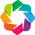

[clustered_heatmap_hv] Row clustering done (method=average, OLO=True).
[clustered_heatmap_hv] Column clustering done (method=average, OLO=True).


[clustered_heatmap_hv] HTML saved at: c:\Users\benja\Desktop\workspace\ItalianEdge\examples\results\soluciones_wang.html


,Solution 1,Solution 2,wang,jaccard,discrepancy,score,z_score
0,10,33,0.901071,0.200472,0.700599,0.700599,1.622038
1,2,33,0.899107,0.199656,0.699451,0.699451,1.614839
2,10,49,0.892336,0.193499,0.698837,0.698837,1.610989
3,10,74,0.892336,0.193499,0.698837,0.698837,1.610989
4,2,74,0.890521,0.193007,0.697514,0.697514,1.602688
5,2,49,0.890521,0.193007,0.697514,0.697514,1.602688
6,10,39,0.897024,0.208695,0.688329,0.688329,1.545082
7,2,39,0.895848,0.208257,0.687591,0.687591,1.540452
8,8,33,0.892994,0.207295,0.685699,0.685699,1.528589
9,9,33,0.892994,0.207295,0.685699,0.685699,1.528589


In [14]:
# Using as reference the wang_sim_matrix and jaccard_equivalent clusters
# I create a similarity matrix according to semantic similarity and recognized 
# equivalent clusters.
wang_solution_matrix, wang_enriched_df = gene_similarity.solution_go_similarity_from_dataframe(
    genes_symbols,
    wang_sim_matrix,
    "Wang",
    jaccard_equivalents_df,
    scm_sets,
    normalize_matrix=True,
)
actions.save_matrix(wang_solution_matrix, RESULTS_DIR / "wang_solution_matrix.npy")
heatmaps.plot_clustered_heatmap(
    wang_solution_matrix,
    labels=labels,
    clustering=heatmaps.ClusteringOptions(linkage_method="average", optimal_leaf_order=True),
    save_filepath=str(RESULTS_DIR / "soluciones_wang.html"),
)


# Recognize all the solution pairs with discrepancy between composition index and 
# semantic index using z_score.
options = ssd.DiscrepancyOptions(
    direction="wang_over_jaccard",
    z_threshold=1.5,
)
pairs_df, outliers_df = ssd.identify_discrepant_solution_pairs(
    wang_solution_matrix, Jaccard_Matrix,
    options=options,
)
display(outliers_df)
fig = ssd.plot_discrepancy_summary(wang_solution_matrix, Jaccard_Matrix, outliers_df)
fig.show()

## Summary study from solutions.

<div style="text-align: justify">

This closing section ties the three solution-level analyses together into a single, concrete example, using `semantic_structural_discrepancy` as the entry point. Rather than reading the Wang/Jaccard discrepancy score in isolation, we cross-reference the flagged solution pairs (`outliers_df`) against the raw cluster composition of the population (`scm_index`) and the structural-equivalence table (`jaccard_equivalents_df`) built earlier from `find_equivalent_clusters_jaccard`:

- **`scm_index`** gives, for each discrepant solution, the underlying gene-index clusters that make it up — independent of any GO annotation, this is the raw partition that produced the discrepancy.
- **`jaccard_equivalents_df`** reports, for every pair of solutions, which clusters are near-duplicates in composition (high Jaccard similarity). Filtering this table to the rows involving a discrepant solution shows whether that solution's clusters echo something already present elsewhere in the population.
- Crossing both lets us split the discrepant solutions into two groups:
    - Solutions with **no equivalent matches**: compositionally singular partitions that also stand out on the Wang/Jaccard axis. These are the strongest candidates for manual biological review, since their divergence cannot be explained away as a near-duplicate of another solution.
    - Solutions **with equivalent matches**: their discrepancy score is driven mainly by the semantic (Wang) side, since their structural composition is already represented elsewhere in the population.

The example below builds this crossed summary and highlights the compositionally singular subset.

To complement the discrepancy-driven view above, `gene_overlap` (imported as `cds`) lets us zoom into the gene level of the equivalent-cluster pairs already identified by `find_equivalent_clusters_jaccard` (`jaccard_equivalents_df`). Given a `Solution 1 / Cluster 1 / Solution 2 / Cluster 2` table such as `jaccard_equivalents_df`, and `scm_sets` to resolve each `(solution, cluster)` pair into its gene set, it computes the shared (intersection) or disjoint (symmetric difference) genes for every pair, without any extra similarity filtering:

- **Shared genes** across structurally-equivalent clusters point to a stable "biological core" that keeps reappearing regardless of which solution produced it.
- **Disjoint genes** reveal the part of each cluster that is *not* explained by the match, i.e. genes contributed by only one of the two solutions.

From either gene-set column, `compute_gene_frequencies` counts how often each gene shows up across all cluster pairs, and `compute_frequency_cutoff` applies Otsu's method to separate incidental genes (appearing in a handful of pairs) from recurrent ones, without a manually chosen threshold — `plot_frequency_cutoff` renders that cut for a visual sanity check. Finally, `summarize_genes` ties it together: it filters to the recurrent genes, and returns their pairwise biological (Wang) similarity submatrix alongside their set co-occurrence Jaccard matrix, so the "biological core" identified structurally can also be inspected semantically.

## Functions

| Module | Function | Description |
|---|---|---|
| Gene overlap | `compute_gene_overlap_dataframe(df, solution_cluster_matrix, mode="shared"\|"disjoint")` | For every cluster pair in `df` (e.g. `jaccard_equivalents_df`), computes the shared (intersection) or disjoint (symmetric difference) gene set, resolving `(Solution, Cluster)` ids through `solution_cluster_matrix` (e.g. `scm_sets`). No similarity/threshold filtering is applied — every row of `df` is processed. |
| Gene overlap | `compute_gene_frequencies(df, gene_column)` | Counts how often each gene appears across the gene sets in `gene_column` ("Shared Genes" or "Disjoint Genes"). Returns a DataFrame sorted by frequency descending. |
| Gene overlap | `compute_frequency_cutoff(freq_df, method="kneed")` | Automatically finds the frequency value that best separates incidental from recurrent genes via Otsu's method on the frequency histogram, replacing a manually-chosen minimum frequency. |
| Gene overlap | `plot_frequency_cutoff(freq_df, cutoff, title=...)` | Histogram of gene frequencies with the cutoff highlighted, to visually audit the automatic cut before/alongside `summarize_genes`. |
| Gene overlap | `summarize_genes(df, gene_column, gene_ids, gene_similarity_matrix, min_gene_frequency=None, top_n_genes_for_plot=30, max_genes=None, label=...)` | Filters genes at or above the frequency cutoff (auto-computed if not given) and returns them alongside their biological similarity submatrix, frequency table/plot, and set co-occurrence Jaccard matrix. |

</div>

In [15]:
groups = [np.where(output == label)[0].tolist() for label in np.unique(output)]
print(groups)

selected = [scm_sets[i] for i in groups[1]]
print(len(selected))

labels_now = []
for i in groups[1]:
    labels_now.append(str(i))

df_selected_equ = jaccard_values.find_equivalent_clusters_jaccard(
    selected,
    labels=labels_now)
display(df_selected_equ.head(5))

# Using the equivalent-cluster pairs found earlier (jaccard_equivalents_df) as the
# reference table, and scm_sets to resolve (Solution, Cluster) ids into gene sets,
# gene_overlap lets us inspect which genes are actually shared between clusters
# that already matched structurally, and which genes remain disjoint despite
# that match.
shared_df = cds.compute_gene_overlap_dataframe(df_selected_equ, scm_sets, mode="shared")
display(shared_df.head(5))

disjoint_df = cds.compute_gene_overlap_dataframe(df_selected_equ, scm_sets, mode="disjoint")
display(disjoint_df.head(5))


[[1, 2, 3, 7, 8, 9, 10, 14, 15, 17, 18, 19, 22, 23, 27, 31, 37, 38, 41, 50, 51, 52, 53, 55, 60, 61, 63, 71, 72, 73, 75, 78, 79, 85, 86, 87, 88, 89, 90, 91, 92, 96, 98, 99, 100, 101, 102, 103, 107, 108, 110, 111, 113, 115], [5, 6, 30, 34, 35, 45, 56, 57, 58, 62, 65, 66, 76, 80, 81, 84, 95, 97, 104, 105, 106, 109, 112], [4, 11, 12, 16, 20, 21, 24, 25, 26, 28, 29, 36, 40, 43, 44, 46, 47, 48, 64, 67, 68, 69, 70, 77, 82, 83, 93, 94, 114], [33, 49, 74], [0, 13, 32, 39, 42, 54, 59]]
23


,Solution 1,Solution 2,Cluster 1,Cluster 2,Jaccard Similarity
0,5,6,3,0,0.796748
1,5,6,2,3,0.734300
2,5,6,0,1,0.359788
3,5,6,1,2,0.263566
4,5,30,2,1,0.676471


,Solution 1,Cluster 1,Solution 2,Cluster 2,Shared Genes
0,5,3,6,0,"{NR2C2, BRD3, DHFR, PPP1R3F, THAP3, KLF11, ZIC..."
1,5,2,6,3,"{VTA1, SPCS3, IRS2, KIF13A, RANGRF, THOC7, SGT..."
2,5,0,6,1,"{ECE2, TSPAN15, RNF34, ALG13, KDM5D, CORO7, NL..."
3,5,1,6,2,"{VIL1, SPESP1, NUDCD2, SURF4, HOOK1, MSTO1, NE..."
4,5,2,30,1,"{VTA1, SPCS3, IRS2, KIF13A, RANGRF, THOC7, SGT..."


,Solution 1,Cluster 1,Solution 2,Cluster 2,Disjoint Genes
0,5,3,6,0,"{IL1RAP, NMRAL1, TERF1, PHF8, MAPK9, MDM4, ETA..."
1,5,2,6,3,"{ALKBH7, PARP8, AGGF1, UBR4, TMEM129, MRPS10, ..."
2,5,0,6,1,"{PARP8, USP8, MDM4, COL4A2, PTPMT1, KLHL18, ND..."
3,5,1,6,2,"{AGGF1, USP8, MRPS10, COL4A2, PTPMT1, B3GNT9, ..."
4,5,2,30,1,"{PARP8, UBR4, TMEM129, MRPS10, RNF34, KDM5D, S..."


In [16]:
# Frequency of each gene across the shared-gene sets, with an automatic Otsu
# cutoff separating incidental genes from recurrently-shared ones, and a
# biological (Wang) + co-occurrence (Jaccard) summary of the selected genes.
shared_freq_df = cds.compute_gene_frequencies(shared_df, "Shared Genes")
shared_cutoff = cds.compute_frequency_cutoff(shared_freq_df)
fig = cds.plot_frequency_cutoff(shared_freq_df, shared_cutoff, title="Shared genes frequency cutoff")
fig.show()

result = cds.summarize_genes(
    shared_df,
    gene_column="Shared Genes",
    gene_ids=genes_symbols,
    gene_similarity_matrix=wang_sim_matrix,
    label="Shared Genes",
)
print(f"Selected genes (>= frequency {result.cutoff_used}): {result.selected_genes}")
display(result.similarity_submatrix)
display(result.cooccurrence_df)
result.frequency_figure.show()


Selected genes (>= frequency 253): ['ABHD12', 'ACTG1', 'AGAP3', 'AGPAT3', 'AIG1', 'AK3', 'ANAPC16', 'ANAPC7', 'ANGPTL4', 'AP2A1', 'APPL2', 'ARHGAP24', 'ARID1B', 'ARID2', 'ARID5B', 'ASAP1', 'B3GALNT2', 'B3GALT6', 'BAZ1A', 'BCL2L10', 'BEND5', 'BRD3', 'BRWD1', 'BRWD3', 'C1orf56', 'CALM1', 'CAMK2N2', 'CAMTA1', 'CAPRIN2', 'CCDC136', 'CCDC47', 'CDC42SE1', 'CLCN2', 'CMTM6', 'COL13A1', 'COQ2', 'COXFA4', 'CRIPT', 'CRLS1', 'DAZAP1', 'DCLRE1C', 'DDOST', 'DDX20', 'DDX54', 'DENR', 'DHFR', 'DLC1', 'DMRT3', 'DNAJC10', 'DOCK6', 'DOCK7', 'DYNC1H1', 'DYNLRB1', 'E2F6', 'ECE2', 'ECHDC1', 'ENAH', 'ENOPH1', 'FAM53C', 'FBXO30', 'FOXH1', 'FOXO3', 'GALNT1', 'GATAD2A', 'GET4', 'GLIS3', 'GNAL', 'GNAT1', 'GOLPH3', 'GON4L', 'GPM6B', 'GPR12', 'GPR21', 'HECTD2', 'HES6', 'HLCS', 'HM13', 'HMG20A', 'HSBP1L1', 'IER3IP1', 'INSC', 'INTS6', 'IREB2', 'IRF2BP2', 'IRS2', 'ITM2B', 'KANK4', 'KIF13A', 'KLF11', 'KPNA4', 'KRT23', 'KRT82', 'KYNU', 'LGALS16', 'LGMN', 'LIN7C', 'LMBRD1', 'LONP2', 'LSM2', 'MAFK', 'MAGED2', 'MAGEF1', 'M

,ABHD12,ACTG1,AGAP3,AGPAT3,AIG1,AK3,ANAPC16,ANAPC7,ANGPTL4,AP2A1,...,ZIC4,ZNF117,ZNF148,ZNF224,ZNF358,ZNF497,ZNF626,ZNF655,ZNF672,ZNF704
ABHD12,1.000000,0.111539,0.183983,0.321619,0.287479,0.199021,0.192482,0.181056,0.128206,0.092905,...,0.043238,0.032778,0.049861,0.036903,0.042025,0.028185,0.038355,0.028497,0.026196,0.026196
ACTG1,0.111539,1.000000,0.097644,0.049752,0.032316,0.088584,0.122178,0.171212,0.247035,0.168670,...,0.143635,0.116935,0.172987,0.140616,0.153064,0.103771,0.144024,0.092146,0.092070,0.092070
AGAP3,0.183983,0.097644,1.000000,0.121065,0.123996,0.130708,0.356676,0.312576,0.151715,0.106840,...,0.053751,0.041672,0.075445,0.044295,0.067891,0.036878,0.050240,0.037621,0.035823,0.035823
AGPAT3,0.321619,0.049752,0.121065,1.000000,0.176483,0.227561,0.105513,0.094245,0.049070,0.072656,...,0.029301,0.019818,0.024051,0.018923,0.028612,0.017253,0.021570,0.017479,0.017981,0.017981
AIG1,0.287479,0.032316,0.123996,0.176483,1.000000,0.122702,0.104677,0.088811,0.029697,0.046866,...,0.022432,0.018331,0.018423,0.017282,0.021301,0.016157,0.020089,0.016396,0.017131,0.017131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF497,0.028185,0.103771,0.036878,0.017253,0.016157,0.021455,0.054342,0.050750,0.110041,0.102141,...,0.732042,0.821155,0.726350,0.940385,0.448912,1.000000,0.857155,0.690711,0.878434,0.878434
ZNF626,0.038355,0.144024,0.050240,0.021570,0.020089,0.026356,0.073149,0.067049,0.113485,0.090710,...,0.780064,0.887548,0.641654,0.892543,0.530907,0.857155,1.000000,0.748554,0.912618,0.912618
ZNF655,0.028497,0.092146,0.037621,0.017479,0.016396,0.021635,0.072447,0.075714,0.101790,0.068760,...,0.623441,0.591832,0.546437,0.700097,0.358411,0.690711,0.748554,1.000000,0.697433,0.697433
ZNF672,0.026196,0.092070,0.035823,0.017981,0.017131,0.020617,0.050311,0.047285,0.087998,0.065730,...,0.756227,0.754324,0.590481,0.814608,0.411634,0.878434,0.912618,0.697433,1.000000,1.000000


,ABHD12,ACTG1,AGAP3,AGPAT3,AIG1,AK3,ANAPC16,ANAPC7,ANGPTL4,AP2A1,...,ZIC4,ZNF117,ZNF148,ZNF224,ZNF358,ZNF497,ZNF626,ZNF655,ZNF672,ZNF704
ABHD12,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AGAP3,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AGPAT3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AIG1,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF497,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ZNF626,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ZNF655,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ZNF672,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [17]:
disjoint_freq_df = cds.compute_gene_frequencies(disjoint_df, "Disjoint Genes")
disjoint_cutoff = cds.compute_frequency_cutoff(disjoint_freq_df)
fig = cds.plot_frequency_cutoff(disjoint_freq_df, disjoint_cutoff, title="Disjoint genes frequency cutoff")
fig.show()

result = cds.summarize_genes(
    disjoint_df,
    gene_column="Disjoint Genes",
    gene_ids=genes_symbols,
    gene_similarity_matrix=wang_sim_matrix,
    label="Disjoint Genes",
)
print(f"Selected genes (>= frequency {result.cutoff_used}): {result.selected_genes}")
display(result.similarity_submatrix)
display(result.cooccurrence_df)
result.frequency_figure.show()

Selected genes (>= frequency 270): ['BMPR2', 'C1QTNF1', 'ESAM', 'EXOSC3', 'OSR2', 'SSH1', 'CAND1', 'LYST', 'RNF169', 'CD28', 'TBRG4', 'AMMECR1', 'EPB41', 'KIF5A', 'EFNA5', 'AGGF1', 'RWDD2B', 'KDM2B', 'ERMN', 'ING4', 'LGALS8', 'ORMDL2']


,BMPR2,C1QTNF1,ESAM,EXOSC3,OSR2,SSH1,CAND1,LYST,RNF169,CD28,...,EPB41,KIF5A,EFNA5,AGGF1,RWDD2B,KDM2B,ERMN,ING4,LGALS8,ORMDL2
BMPR2,1.000000,0.157219,0.134714,0.159045,0.417484,0.212662,0.198498,0.089887,0.126568,0.278453,...,0.129230,0.112088,0.265593,0.214816,0.0,0.271076,0.211878,0.292489,0.110689,0.086280
C1QTNF1,0.157219,1.000000,0.123998,0.111080,0.173768,0.173261,0.160742,0.098973,0.127740,0.284667,...,0.127933,0.082088,0.156551,0.140822,0.0,0.108107,0.227148,0.272643,0.044670,0.115537
ESAM,0.134714,0.123998,1.000000,0.115697,0.141063,0.253340,0.181089,0.148545,0.175733,0.154442,...,0.187425,0.199992,0.312097,0.307696,0.0,0.101276,0.208777,0.201622,0.096056,0.138204
EXOSC3,0.159045,0.111080,0.115697,1.000000,0.159007,0.202472,0.186506,0.092178,0.269900,0.195534,...,0.096323,0.096571,0.127927,0.111597,0.0,0.182677,0.116909,0.281559,0.114397,0.221888
OSR2,0.417484,0.173768,0.141063,0.159007,1.000000,0.216794,0.263537,0.092266,0.131192,0.265716,...,0.110391,0.113179,0.160486,0.243613,0.0,0.346569,0.226319,0.302569,0.097551,0.106983
SSH1,0.212662,0.173261,0.253340,0.202472,0.216794,1.000000,0.239616,0.148468,0.236437,0.219064,...,0.334169,0.188159,0.248761,0.183137,0.0,0.181008,0.342870,0.328730,0.088760,0.155956
CAND1,0.198498,0.160742,0.181089,0.186506,0.263537,0.239616,1.000000,0.145861,0.423012,0.198541,...,0.170096,0.138190,0.128348,0.169394,0.0,0.189011,0.174767,0.369031,0.084825,0.159637
LYST,0.089887,0.098973,0.148545,0.092178,0.092266,0.148468,0.145861,1.000000,0.186244,0.194182,...,0.236557,0.173876,0.125318,0.154038,0.0,0.084033,0.175896,0.130022,0.300591,0.100398
RNF169,0.126568,0.127740,0.175733,0.269900,0.131192,0.236437,0.423012,0.186244,1.000000,0.167168,...,0.228908,0.141069,0.136845,0.156980,0.0,0.178163,0.156992,0.323342,0.133166,0.196855
CD28,0.278453,0.284667,0.154442,0.195534,0.265716,0.219064,0.198541,0.194182,0.167168,1.000000,...,0.166129,0.117601,0.268240,0.208146,0.0,0.200179,0.176426,0.326448,0.064002,0.129956


,BMPR2,C1QTNF1,ESAM,EXOSC3,OSR2,SSH1,CAND1,LYST,RNF169,CD28,...,EPB41,KIF5A,EFNA5,AGGF1,RWDD2B,KDM2B,ERMN,ING4,LGALS8,ORMDL2
BMPR2,1.000000,0.409639,0.274047,0.409639,0.420290,0.153457,0.284369,0.353175,0.505519,0.427966,...,0.408805,0.349398,0.348178,0.418803,0.418803,0.340206,0.516588,0.322314,0.401330,0.324948
C1QTNF1,0.409639,1.000000,0.478261,1.000000,0.330661,0.157343,0.386555,0.338742,0.254753,0.771739,...,0.368421,0.310484,0.347280,0.263780,0.263780,0.297521,0.457547,0.385650,0.340659,0.252567
ESAM,0.274047,0.478261,1.000000,0.478261,0.400844,0.173759,0.774194,0.625616,0.200000,0.429825,...,0.224105,0.282051,0.685864,0.281437,0.281437,0.189394,0.312102,0.301053,0.232323,0.193738
EXOSC3,0.409639,1.000000,0.478261,1.000000,0.330661,0.157343,0.386555,0.338742,0.254753,0.771739,...,0.368421,0.310484,0.347280,0.263780,0.263780,0.297521,0.457547,0.385650,0.340659,0.252567
OSR2,0.420290,0.330661,0.400844,0.330661,1.000000,0.251938,0.470320,0.470320,0.393939,0.290061,...,0.174074,0.320833,0.516908,0.242063,0.242063,0.159091,0.331858,0.223577,0.202429,0.263830
SSH1,0.153457,0.157343,0.173759,0.157343,0.251938,1.000000,0.188889,0.204503,0.171533,0.148551,...,0.132616,0.231969,0.178908,0.166355,0.166355,0.200787,0.138520,0.244813,0.134100,0.167653
CAND1,0.284369,0.386555,0.774194,0.386555,0.470320,0.188889,1.000000,0.516588,0.254902,0.367965,...,0.177570,0.298969,0.552239,0.287785,0.287785,0.134328,0.356009,0.269639,0.177645,0.191919
LYST,0.353175,0.338742,0.625616,0.338742,0.470320,0.204503,0.516588,1.000000,0.254902,0.303093,...,0.173184,0.267606,0.868263,0.287785,0.287785,0.134328,0.253669,0.232990,0.159136,0.247357
RNF169,0.505519,0.254753,0.200000,0.254753,0.393939,0.171533,0.254902,0.254902,1.000000,0.284553,...,0.223301,0.354839,0.289256,0.443155,0.443155,0.293617,0.232990,0.232990,0.177645,0.532468
CD28,0.427966,0.771739,0.429825,0.771739,0.290061,0.148551,0.367965,0.303093,0.284553,1.000000,...,0.349241,0.317797,0.316239,0.279167,0.279167,0.298701,0.446078,0.398104,0.416058,0.284768


## References.
<div style="text-align: justify">

[1] L. A. Bejarano, H. E. Espitia, and C. E. Montenegro. “Clustering analysis for the Pareto optimal front in Multi-Objective Optimization”. In: Computation 10.3 (2022), p. 37. doi: 10.3390/computation10030037.  
[2] The Gene Ontology Consortium. “Gene Ontology: tool for the unification of Biology”. In: Nature Genetics 25 (2000), pp. 25–29. url: https://web.stanford.edu/group/sherlocklab/pdfs/GO_NATURE_GENETICS_2000.pdf.  
[3] Patrick D’haeseleer. “How does gene expression clustering work?” In: Nature Biotechnology 23.12 (2005), pp. 1499–1501. doi: 10.1038/nbt1205-1499.  
[4] Susmita Datta and Somnath Datta. “Methods for evaluating clustering algorithms for gene expression data using a reference set of functional classes”. In: BMC Bioinformatics 7.1 (2006), pp. 1–14. doi: 10.1186/1471-2105-7-397.  
[5] Kalyanmoy Deb et al. “A fast and elitist multiobjective genetic algorithm: NSGA-II”. In: IEEE Transactions on Evolutionary Computation 6.2 (2002), pp. 182–197. doi: 10.1109/4235.996017.  
[6] Antonio López Jaimes, Saúl Zapotecas-Martínez, and Carlos Coello. “An Introduction to Multiobjective Optimization Techniques”. In: (2011). url:
https://www.researchgate.net/publication/283325825_An_Introduction_to_Multiobjective_Optimization_Techniques.  
[7] S. Swift et al. “Consensus clustering and functional interpretation of gene-expression data”. In: Genome Biology 5.11 (2004), R94. doi: 10.1186/gb-2004-5-11-r94. url: https://doi.org/10.1186/gb-2004-5-11-r94.  
[8] El-Ghazali Talbi. Metaheuristics: From Design to Implementation. John Wiley & Sons, 2009.  
[9] Reimand J, Kull M, Peterson H, Hansen J, Vilo J. g:Profiler--a web-based toolset for functional profiling of gene lists from large-scale experiments. Nucleic Acids Res. 2007 Jul;35(Web Server issue):W193-200. doi: 10.1093/nar/gkm226. Epub 2007 May 3. PMID: 17478515; PMCID: PMC1933153.  
[10] Liis Kolberg, Uku Raudvere, Ivan Kuzmin, Priit Adler, Jaak Vilo, Hedi Peterson, g:Profiler—interoperable web service for functional enrichment analysis and gene identifier mapping (2023 update), Nucleic Acids Research, Volume 51, Issue W1, 5 July 2023, Pages W207–W212, https://doi.org/10.1093/nar/gkad347   
[11] MyGene.info: gene annotation query as a service Chunlei Wu, Adam Mark, Andrew I. Su bioRxiv 009332; doi: https://doi.org/10.1101/009332  
[12] Ashburner M, Ball CA, Blake JA, Botstein D, Butler H, Cherry JM, Davis AP, Dolinski K, Dwight SS, Eppig JT, Harris MA, Hill DP, Issel-Tarver L, Kasarskis A, Lewis S, Matese JC, Richardson JE, Ringwald M, Rubin GM, Sherlock G. Gene ontology: tool for the unification of biology. The Gene Ontology Consortium. Nat Genet. 2000 May;25(1):25-9. doi: 10.1038/75556. PMID: 10802651; PMCID: PMC3037419.  
[13] GO Association File (GAF) format. (2026, 1 July). Gene Ontology Resource. https://geneontology.org/docs/go-annotation-file-gaf-format-2.1/  
[14] Mellina-Andreu, J. L., Cisterna-Garcia, A., & Botia, J. A. (2025). GO3: A fast and lightweight library for semantic similarity of GO terms and genes. SoftwareX, 35, 102755. https://doi.org/10.1016/j.softx.2026.102755  
[15] GO3 documentation. (n.d.). https://go3.readthedocs.io/en/latest/  
[16] Sánchez, D., Batet, M., & Isern, D. (2010). Ontology-based information content computation. Knowledge-Based Systems, 24(2), 297-303. https://doi.org/10.1016/j.knosys.2010.10.001  
[17] Monti, S., Tamayo, P., Mesirov, J., & Golub, T. (2003). Consensus clustering: A resampling-based
method for class discovery and visualization of gene expression microarray data.
*Machine Learning, 52*(1), 91–118. https://doi.org/10.1023/A:1023949509487   
[18] James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). An Introduction to Statistical Learning. En Springer texts in statistics. https://doi.org/10.1007/978-1-4614-7138-7  
[19] Hierarchical clustering (scipy.cluster.hierarchy) — SciPy v1.18.0 Manual. (n.d.). https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html  
[20] https://www.mathworks.com/help/stats/cophenet.html
[21] Yu, G. (n.d.). Chapter 15 Visualization of functional enrichment result | Biomedical Knowledge Mining using GOSemSim and clusterProfiler. https://yulab-smu.top/biomedical-knowledge-mining-book/enrichplot.html   
[22] 
[23] Thomas, S. (2023, 17 julio). Z-Score: Formula, Examples & How to Interpret It | Outlier. Outlier. https://articles.outlier.org/z-score-formula-examples-and-how-to-interpret
[24] Walpole, R. E. (2012). Probability and Statistics for Engineers and Scientists.

</div>